<a href="https://colab.research.google.com/github/TRIAXIS-MOF/TRIAXIS-MOF/blob/main/Cost%20Calculation%2C%20MCDM%20Screening%2C%20and%20Energy%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Instalasi dan Import Library Phyton

In [ ]:
!pip install adjustText
!pip install rdkit
!pip install joypy

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, kendalltau

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgb, to_hex
from adjustText import adjust_text
import joypy
import contextlib, io

from IPython.display import display

from rdkit import Chem
from rdkit.Chem import Descriptors

from google.colab import files

from matplotlib.patches import Patch
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import plotly.graph_objects as go
from plotly.subplots import make_subplots

2. Mengunggah File Database MOF Berisi Parameter Sintesis

In [ ]:
# pengunggahan dan pembacaan file excel ke dalam google colab
uploaded = files.upload()

Synthesis_Parameter = "Synthesis_Parameter_3.xlsx"

Syn1 = pd.read_excel(Synthesis_Parameter, sheet_name=0).fillna(0)
Syn2 = pd.read_excel(Synthesis_Parameter, sheet_name=1).fillna(0)
Syn3 = pd.read_excel(Synthesis_Parameter, sheet_name=2).fillna(0)

print("Preview of Sheet 1 (first 5 rows):")
display(Syn1.head())
print("Preview of Sheet 2 (first 5 rows):")
display(Syn2.head())
print("Preview of Sheet 3 (first 5 rows):")
display(Syn3.head())

print("\nSheet 1 → Rows:", len(Syn1), " Columns:", len(Syn1.columns))
print("Sheet 2 → Rows:", len(Syn2), " Columns:", len(Syn2.columns))
print("Sheet 3 → Rows:", len(Syn3), " Columns:", len(Syn3.columns))

print("\nColumn names in Sheet 1:", Syn1.columns.tolist())
print("Column names in Sheet 2:", Syn2.columns.tolist())
print("Column names in Sheet 3:", Syn3.columns.tolist())

Saving Synthesis_Parameter_3.xlsx to Synthesis_Parameter_3 (4).xlsx
Preview of Sheet 1 (first 5 rows):


,MOF_Name,Name,Link_DOI,CCDC_Link,Uptake_Grav (wt. %),Uptake_Vol (g H2/L),Uptake Grav - Working Cap [%wt],Uptake Vol - Working Cap [g/L],Pressure (bar),Temperature (oC),...,SMILES2,Vendor_Name2,Max_Amount2 (g),Min_Purity2,Linker2_Mass (mg),Linker2_Mol (mmol),Linker1 (€/g),Linker1 (€),Linker2 (€/g),Linker2 (€)
0,HUNCIE,ZJU-31,http://dx.doi.org/10.1021/acs.cgd.5b00675,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.69,46.16,13.110583,43.382348,autogenous,80.0,...,0,0,0.0,0.0,0.0,0.00,161.500,0.807500,0.0000,0.000000
1,SUNLAP,0,https://doi.org/10.1002/anie.200806227,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.37,46.97,12.874313,44.715887,autogenous,80.0,...,0,0,0.0,0.0,0.0,0.00,0.000,0.000000,0.0000,0.000000
2,VETMIS,0,http://dx.doi.org/10.1002/chem.201203093,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.27,47.75,12.629085,44.990621,autogenous,85.0,...,0,0,0.0,0.0,0.0,0.00,0.000,0.000000,0.0000,0.000000
3,BAZFUF,0,http://dx.doi.org/10.1021/ic201376t,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.50,48.58,11.698570,45.064270,autogenous,85.0,...,0,0,0.0,0.0,0.0,0.00,6.868,0.208787,0.0000,0.000000
4,BAZFUF01,DUT-23(Cu),http://dx.doi.org/10.1002/chem.201101383,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.44,48.60,11.653757,44.895630,autogenous,80.0,...,0,0,0.0,0.0,42.0,0.27,48.280,5.262520,0.2907,0.012209


Preview of Sheet 2 (first 5 rows):


,Solvent,Solvent_Code,Solvent_CAS,Vendor_Name_Analytical_Grade,Max_Amount_Analytical_Grade (L),Min_Purity_Analytical_Grade,Rel_Price_Analytical_Grade (€/ml),Rel_Price_Analytical_Grade (Rp./ml),Vendor_Name_Technical_Grade,Max_Amount_Technical_Grade (L),Min_Purity_Technical_Grade,Rel_Price_Technical_Grade (€/ml),Rel_Price_Technical_Grade (Rp./ml)
0,DEA,0,91-66-7,Sigma Aldrich,1.000000,0.99,0.079960,1501.0,PT Graha Jaya Pratama Kinerja,215.143121,0.85,0.002076,39.153232
1,DMA,1,127-19-5,Sigma Aldrich,8.000000,0.999,0.228585,4291.0,Trimax Chemicals,52.301255,0.98,0.001961,36.990220
2,DMAc,2,127-19-5,Sigma Aldrich,8.000000,0.999,0.228585,4291.0,Trimax Chemicals,52.301255,0.98,0.001961,36.990220
3,DMF,3,68-12-2,Sigma Aldrich,200.000000,0.998,0.174728,3280.0,Trimax Chemicals,200.000000,0.99,0.000654,12.330073
4,DEF,4,68-84-2,Sigma Aldrich,0.110132,0.99,1.023024,19204.2,"Lonwin Industry Group Limited Co., Ltd.",220.264317,0.99,0.000391,7.384367


Preview of Sheet 3 (first 5 rows):


,Metal,Num_Hidrate,Metal_Code,Metal_CAS,Vendor_Name_Analytical_Grade,Max_Amount_Analytical_Grade (g),Min_Purity_Analytical_Grade,Rel_Price_Analytical_Grade (€/g),Rel_Price_Analytical_Grade (Rp./g),Vendor_Name_Technical_Grade,Max_Amount_Technical_Grade (g),Min_Purity_Technical_Grade,Rel_Price_Technical_Grade (€/g),Rel_Price_Technical_Grade (Rp./g)
0,Cu(NO₃)₂,2.0,28,19004-19-3,Sigma Aldrich,500,0.98,0.446196,8376.0000,W&Q Fine Chemicals,25000.0,0.99,0.00255,48.10014
1,0,2.5,29,19004-19-4,Sigma Aldrich,500,0.98,0.446196,8376.0000,W&Q Fine Chemicals,25000.0,0.99,0.00255,48.10014
2,0,3.0,30,10031-43-3,Sigma Aldrich,100,0.99,1.128809,21190.0000,W&Q Fine Chemicals,25000.0,0.99,0.00255,48.10014
3,0,4.0,31,13478-38-1,Sigma Aldrich,50,0.98,1.638343,30754.9770,W&Q Fine Chemicals,25000.0,0.99,0.00255,48.10014
4,0,6.0,32,13778-31-9,Sigma Aldrich,100,0.98,3.121475,58596.3246,W&Q Fine Chemicals,25000.0,0.99,0.00255,48.10014



Sheet 1 → Rows: 68  Columns: 53
Sheet 2 → Rows: 27  Columns: 13
Sheet 3 → Rows: 31  Columns: 14

Column names in Sheet 1: ['MOF_Name', 'Name', 'Link_DOI', 'CCDC_Link', 'Uptake_Grav (wt. %)', 'Uptake_Vol (g H2/L)', 'Uptake Grav - Working Cap [%wt]', 'Uptake Vol - Working Cap [g/L]', 'Pressure (bar)', 'Temperature (oC)', 'Time (h)', 'Yield', 'Product (mg)', 'Solvent_Name', 'Solvent_Code', 'Solvent_Volume (mL)', 'Additive_Name', 'Additive_Code', 'Additive_Volume (mL)', 'Modulator_Name', 'Modulator_Code', 'Concentration (% or M)', 'Modulator Sol_Volume (mL)', 'Concentration (%w/w)', 'Modulator_Volume (mL)', 'Metal_Name', 'Metal_Code', 'Metal_Mass (mg)', 'Metal_Mol (mmol)', 'Linker1_Name', 'CAS1', 'Norm_Name1', 'Name1', 'SMILES1', 'Vendor_Name1', 'Max_Amount1 (g)', 'Min_Purity1', 'Linker1_Mass (mg)', 'Linker1_Mol (mmol)', 'Linker2_Name', 'CAS2', 'Norm_Name2', 'Name2', 'SMILES2', 'Vendor_Name2', 'Max_Amount2 (g)', 'Min_Purity2', 'Linker2_Mass (mg)', 'Linker2_Mol (mmol)', 'Linker1 (€/g)', 'L

3. Menghitung Biaya Sintesis MOF

In [ ]:
# perhitungan harga bahan dan biaya penyimpanan hidrogen pada MOFs
Synthesis_Parameter = "Synthesis_Parameter_3.xlsx"
Synthesis_Parameter_Price = "Synthesis_Parameter_Price.xlsx"
eur_to_usd = 1.15  # kurs euro ke USD

# nama kolom "kode bahan" di sheet 1
solvent_col_name   = "Solvent_Code"
additive_col_name  = "Additive_Code"
modulator_col_name = "Modulator_Code"
metal_col_name     = "Metal_Code"

xls = pd.ExcelFile(Synthesis_Parameter)
Syn1 = pd.read_excel(Synthesis_Parameter, sheet_name=xls.sheet_names[0])
Syn2 = pd.read_excel(Synthesis_Parameter, sheet_name=xls.sheet_names[1])
Syn3 = pd.read_excel(Synthesis_Parameter, sheet_name=xls.sheet_names[2]) if len(xls.sheet_names) > 2 else None

# penyamaan format kode bahan
def normalize_code_column(df, colname):
    """Normalize code columns to consistent string format."""
    if colname in df.columns:
        df[colname] = pd.to_numeric(df[colname], errors='coerce')
        df[colname] = df[colname].fillna(-9999).astype(int)
        df[colname] = df[colname].astype(str)
        df.loc[df[colname] == '-9999', colname] = ''

# penerapan fungsi normalisasi kode
for col in [solvent_col_name, additive_col_name, modulator_col_name, metal_col_name]:
    normalize_code_column(Syn1, col)  # di sheet 1

if "Solvent_Code" in Syn2.columns:
    normalize_code_column(Syn2, "Solvent_Code")
if "Metal_Code" in Syn3.columns:
    normalize_code_column(Syn3, "Metal_Code")

# pembuatan kamus (lookup dictionary) harga bahan
s2_code_col = "Solvent_Code"
s2_price_col = "Rel_Price_Technical_Grade (€/ml)"
s3_code_col = "Metal_Code"
s3_price_col = "Rel_Price_Technical_Grade (€/g)"

print("Syn2 columns:", Syn2.columns.tolist())
if Syn3 is not None:
    print("Syn3 columns:", Syn3.columns.tolist())

# lookup dictionaries
if s2_code_col in Syn2.columns and s2_price_col in Syn2.columns:
    lookup_dict_s2 = dict(zip(Syn2[s2_code_col].astype(str).str.strip(), Syn2[s2_price_col]))
else:
    raise ValueError("Check Syn2 headers — expected columns: 'Solvent_Code' and 'Rel_Price_Technical_Grade (€/ml)'")

lookup_dict_s3 = {}
if Syn3 is not None and s3_code_col in Syn3.columns and s3_price_col in Syn3.columns:
    lookup_dict_s3 = dict(zip(Syn3[s3_code_col].astype(str).str.strip(), Syn3[s3_price_col]))
else:
    print("Warning: Metal sheet columns not found — skipping metal lookup.")

# pencocokan kode bahan dengan harga satuan
Syn1["Solvent_Price (€/mL)"]   = Syn1[solvent_col_name].map(lookup_dict_s2)
Syn1["Additive_Price (€/mL)"]  = Syn1[additive_col_name].map(lookup_dict_s2)
Syn1["Modulator_Price (€/mL)"] = Syn1[modulator_col_name].map(lookup_dict_s2)
Syn1["Metal_Price (€/g)"]      = Syn1[metal_col_name].map(lookup_dict_s3) if Syn3 is not None else 0

Syn1 = Syn1.fillna(0)

# verifikasi hasil pencocokan (diagnostik)
print("Mapping verification:")
print("Unique solvent codes in Syn1:", Syn1[solvent_col_name].unique()[:10])
print("Keys in Syn2 lookup:", list(lookup_dict_s2.keys())[:10])
print("Unmatched solvent codes:",
      [c for c in Syn1[solvent_col_name].unique() if c not in lookup_dict_s2])

# perhitungan harga bahan berdasarkan volume/massa
Syn1["Solvent Price (€)"]   = Syn1["Solvent_Price (€/mL)"]   * Syn1.get("Solvent_Volume (mL)", 0)
Syn1["Additive Price (€)"]  = Syn1["Additive_Price (€/mL)"]  * Syn1.get("Additive_Volume (mL)", 0)
Syn1["Modulator Price (€)"] = Syn1["Modulator_Price (€/mL)"] * Syn1.get("Modulator_Volume (mL)", 0)
Syn1["Metal Price (€)"]     = Syn1["Metal_Price (€/g)"]      * (Syn1.get("Metal_Mass (mg)", 0) / 1000.0)
# metal dibagi 1000 karena konversi mg ke g

# penerapan faktor diskon untuk produksi skala industri
ym = 0.56
ym_linker = 0.67
industrial_mass_mg = 1e7  # 10 kg = 10e7 mg

# mencegah pembagian dengan angka 0
Syn1["Product (mg)"] = Syn1.get("Product (mg)", 1).replace(0, 1)

scale_factor = (Syn1["Product (mg)"] / industrial_mass_mg) ** ym
scale_factor_linker = (Syn1["Product (mg)"] / industrial_mass_mg) ** ym_linker

# penerapan faktor diskon ke semua kolom harga
for col in ["Solvent Price (€)", "Additive Price (€)", "Modulator Price (€)", "Metal Price (€)"]:
    Syn1[col] *= scale_factor

if "Linker1 (€)" in Syn1.columns:
    Syn1["Linker1 (€)"] *= scale_factor_linker
if "Linker2 (€)" in Syn1.columns:
    Syn1["Linker2 (€)"] *= scale_factor_linker

# perhitungan total biaya bahan baku MOFs
Syn1["MOF Total Price (€)"] = (
    Syn1["Solvent Price (€)"] +
    Syn1["Additive Price (€)"] +
    Syn1["Modulator Price (€)"] +
    Syn1["Metal Price (€)"] +
    Syn1.get("Linker1 (€)", 0) +
    Syn1.get("Linker2 (€)", 0)
)

# konversi harga ke satuan euro/kg dan USD/kg
Syn1["MOF Price (€/kg)"] = Syn1["MOF Total Price (€)"] / (Syn1["Product (mg)"] / 1e6)
Syn1["MOF Price (€/kg)"] = Syn1["MOF Price (€/kg)"].replace([float("inf")], 0)

# mengonversi ke USD
Syn1["MOF Price (USD/kg)"] = Syn1["MOF Price (€/kg)"] * eur_to_usd

# perhitungan biaya spesifik penyimpanan hidrogen
# harga MOF (USD/kg MOF) dibagi kapasitas gravimetrik (kg H₂/100 kg MOF)
Syn1["H2 Specific Storage Cost (USD/kg H2)"] = Syn1["MOF Price (USD/kg)"] / (
    Syn1.get("Uptake Grav - Working Cap [%wt]", 0) / 100.0
)

# pembersihan akhir dan penyimpanan hasil ke file baru
Syn1 = Syn1.fillna(0)

# menyimpan file harga MOF
with pd.ExcelWriter(Synthesis_Parameter_Price, engine="openpyxl") as writer:
    Syn1.to_excel(writer, sheet_name="Syn_Param", index=False)
    Syn2.to_excel(writer, sheet_name="Solvent", index=False)
    if Syn3 is not None:
        Syn3.to_excel(writer, sheet_name="Metal", index=False)

print(f"\nFinal results saved to: {Synthesis_Parameter_Price}")
print("\nSheet1 (first 10 rows) — with MOF price and H₂ cost:")
print(Syn1.head(5).to_string(index=False))
print("\nSheet1 (last 10 rows):")
print(Syn1.tail(5).to_string(index=False))

Syn2 columns: ['Solvent', 'Solvent_Code', 'Solvent_CAS', 'Vendor_Name_Analytical_Grade', 'Max_Amount_Analytical_Grade (L)', 'Min_Purity_Analytical_Grade', 'Rel_Price_Analytical_Grade (€/ml)', 'Rel_Price_Analytical_Grade (Rp./ml)', 'Vendor_Name_Technical_Grade', 'Max_Amount_Technical_Grade (L)', 'Min_Purity_Technical_Grade', 'Rel_Price_Technical_Grade (€/ml)', 'Rel_Price_Technical_Grade (Rp./ml)']
Syn3 columns: ['Metal', 'Num_Hidrate', 'Metal_Code', 'Metal_CAS', 'Vendor_Name_Analytical_Grade', 'Max_Amount_Analytical_Grade (g)', 'Min_Purity_Analytical_Grade', 'Rel_Price_Analytical_Grade (€/g)', 'Rel_Price_Analytical_Grade (Rp./g)', 'Vendor_Name_Technical_Grade', 'Max_Amount_Technical_Grade (g)', 'Min_Purity_Technical_Grade', 'Rel_Price_Technical_Grade (€/g)', 'Rel_Price_Technical_Grade (Rp./g)']
Mapping verification:
Unique solvent codes in Syn1: ['1' '3' '4' '10' '' '27' '0']
Keys in Syn2 lookup: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Unmatched solvent codes: ['']

Final res

4. Visualisasi Kontribusi Harga Bahan Baku Terhadap Harga Total MOF

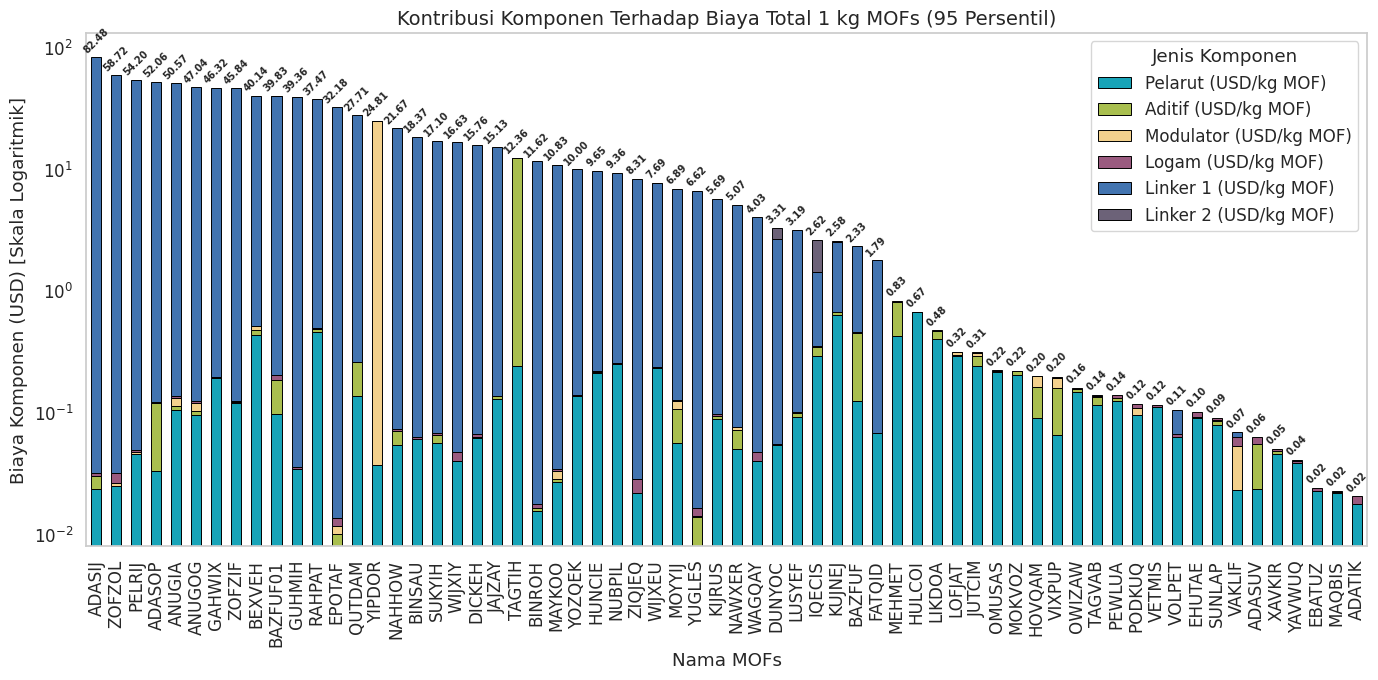

,Solvent Price (USD/kg MOF),Additive Price (USD/kg MOF),Modulator Price (USD/kg MOF),Metal Price (USD/kg MOF),Linker1 (USD/kg MOF),Linker2 (USD/kg MOF),MOF Price (USD/kg),H2 Specific Storage Cost (USD/kg H2)
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.128182,0.203369,0.368021,0.003605,31.912769,0.040869,32.656814,435.821539
std,0.141978,1.460537,3.001952,0.003675,92.772766,0.179883,92.665440,1224.758111
min,0.000000,0.000000,0.000000,0.000213,0.000000,0.000000,0.020698,0.193748
25%,0.038408,0.000000,0.000000,0.001487,0.000000,0.000000,0.215576,3.198487
50%,0.073823,0.004471,0.000099,0.002340,5.293513,0.000000,6.752016,103.052066
75%,0.139992,0.023568,0.001444,0.004007,28.625693,0.000000,28.827044,388.978513
max,0.667731,12.058723,24.758606,0.019991,570.609372,1.200880,571.338645,8548.522363


In [ ]:
eur_to_usd = 1.15

# kolom komponen biaya dalam EUR dikonversi ke USD
for col in ["Solvent Price (€)", "Additive Price (€)", "Modulator Price (€)",
            "Metal Price (€)", "Linker1 (€)", "Linker2 (€)"]:
    if col in Syn1.columns:
        Syn1[col.replace("€", "USD")] = Syn1[col] * eur_to_usd

# Konversi biaya menjadi biaya untuk menghasilkan 1 kg MOF
Syn1["Product (kg)"] = Syn1["Product (mg)"] / 1_000_000
Syn1["scaling_factor"] = Syn1["Product (kg)"].replace(0, np.nan)
Syn1["scaling_factor"] = 1 / Syn1["scaling_factor"]

# memperbarui semua biaya komponen menjadi biaya per 1 kg MOF
for col in ["Solvent Price (USD)", "Additive Price (USD)",
            "Modulator Price (USD)", "Metal Price (USD)",
            "Linker1 (USD)", "Linker2 (USD)"]:
     if col in Syn1.columns:
        Syn1[col.replace(")", "/kg MOF)")] = Syn1[col] * Syn1["scaling_factor"]

# memilih kolom yang berisi biaya tiap bahan pembentuk mof
component_cols = [
    "Solvent Price (USD/kg MOF)",
    "Additive Price (USD/kg MOF)",
    "Modulator Price (USD/kg MOF)",
    "Metal Price (USD/kg MOF)",
    "Linker1 (USD/kg MOF)",
    "Linker2 (USD/kg MOF)"
]
available_components = [c for c in component_cols if c in Syn1.columns]

# menghilangkan data ekstrim (outlier)
MOF_price_95 = Syn1["MOF Price (USD/kg)"].quantile(0.95)
Syn1_plot = Syn1[Syn1["MOF Price (USD/kg)"] <= MOF_price_95].copy()
Syn1_plot.sort_values(by="MOF Price (USD/kg)", ascending=False, inplace=True)
Syn1_plot.set_index("MOF_Name", inplace=True)

# menentukan warna untuk setiap komponen pembentuk mof
colors = [
    "#17A4B8",  # pelarut
    "#A9BF4F",  # aditif
    "#F3D18D",  # modulator
    "#9A5A7F",  # logam
    "#4274B0",  # linker1
    "#6C6278"   # linker2
]
colors = [colors[i] for i in range(len(available_components))]

# membuat diagram batang bertumpuk (stacked bar chart)
ax = Syn1_plot[available_components].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=colors,
    edgecolor='black',
    linewidth=0.7,
    logy=True
)
ax.grid(False)

# mengatur label, judul, dan legenda dalam bahasa indonesia
plt.ylabel("Biaya Komponen (USD) [Skala Logaritmik]")
plt.xlabel("Nama MOFs")
plt.title(
    "Kontribusi Komponen Terhadap Biaya Total 1 kg MOFs (95 Persentil)",
    fontsize=14
)
plt.legend(
    title="Jenis Komponen",
    labels=[
        "Pelarut (USD/kg MOF)",
        "Aditif (USD/kg MOF)",
        "Modulator (USD/kg MOF)",
        "Logam (USD/kg MOF)",
        "Linker 1 (USD/kg MOF)",
        "Linker 2 (USD/kg MOF)"
    ][:len(available_components)],
    bbox_to_anchor=(1, 1),
    loc='upper right'
)

# hitung total biaya per bar (penjumlahan semua komponen)
total_cost = Syn1_plot[available_components].sum(axis=1)
for i, (mof_name, total) in enumerate(total_cost.items()):
    ax.text(
        i,
        total * 1.05,
        f"{total:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        rotation=45
    )
plt.tight_layout()
plt.show()

# Bar Chart
selected_mofs = [
    "ADASIJ","VAKLIF","FATQID","NAWXER",
    "VOLPET","YAVWUQ","YUGLES","MAYKOO","IQECIS"
]

df_sel = Syn1_plot.loc[Syn1_plot.index.intersection(selected_mofs)].copy()

component_cols = [
    "Solvent Price (USD/kg MOF)",
    "Additive Price (USD/kg MOF)",
    "Modulator Price (USD/kg MOF)",
    "Metal Price (USD/kg MOF)",
    "Linker1 (USD/kg MOF)",
    "Linker2 (USD/kg MOF)"
]
component_cols = [c for c in component_cols if c in df_sel.columns]

def darken_color(hex_color, factor=0.6):
    """Membuat warna lebih gelap. factor <1 → lebih gelap"""
    rgb = to_rgb(hex_color)
    dark_rgb = tuple(max(0, c * factor) for c in rgb)
    return to_hex(dark_rgb)

dfp = df_sel[component_cols].copy()
dfp.columns = [c.replace(" (USD/kg MOF)", "") for c in dfp.columns]

# Palet fill
FILL_COLORS = [
    "#17A4B8",  # Deep Teal Extra Bright
    "#A9BF4F",  # Olive Green Extra Bright
    "#F3D18D",  # Antique Gold Extra Bright
    "#9A5A7F",  # Mulberry Shadow Extra Bright
    "#4274B0",  # Midnight Blue Extra Bright
    "#6C6278",  # Charcoal Gray Extra Bright
]

colors_plotly = [(fill, darken_color(fill, 0.6)) for fill in FILL_COLORS]

# Figure
fig = go.Figure()
for col, (FILL_COLORS, border_color) in zip(dfp.columns, colors_plotly):
    fig.add_trace(go.Bar(
        x=dfp.index,
        y=dfp[col],
        name=col,
        marker=dict(
            color=FILL_COLORS,
            opacity=0.90,
            line=dict(color=border_color, width=1.4)
        ),
    ))

# Total Cost di Atas Bar
total_cost = dfp.sum(axis=1)
fig.add_trace(go.Scatter(
    x=dfp.index,
    y=total_cost * 1.05,
    mode="text",
    text=[f"{v:,.2f}" for v in total_cost],
    textposition="top center",
    textfont=dict(size=18, family="Arial", color="black"),
    showlegend=False
))

# Layout
fig.update_layout(
    barmode='stack',

    xaxis_title="MOF",
    yaxis_title="Component Cost (USD/kg MOF) — Log Scale",
    yaxis_type="log",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=18, color="black"),
    margin=dict(l=80, r=40, t=60, b=80),
    shapes=[
        dict(
            type="rect",
            xref="paper", yref="paper",
            x0=0, y0=0, x1=1, y1=1,
            line=dict(color="black", width=2)
        )
    ],
    xaxis=dict(
        showline=True, linewidth=2, linecolor='black',
        ticks="outside",
        tickfont=dict(size=16, family="Arial")
    ),
    yaxis=dict(
        showline=True, linewidth=2, linecolor='black',
        ticks="outside",
        tickfont=dict(size=16, family="Arial")
    ),
    width=1100,
    height=650,
    legend=dict(
        title="Komponen",
        font=dict(size=16, family="Arial"),
        bordercolor="black",
        borderwidth=1
    )
)
fig.show()

# Raincloud Plot
df = Syn1_plot[[
    "Solvent Price (USD/kg MOF)",
    "Additive Price (USD/kg MOF)",
    "Modulator Price (USD/kg MOF)",
    "Metal Price (USD/kg MOF)",
    "Linker1 (USD/kg MOF)",
    "Linker2 (USD/kg MOF)",
    "MOF Price (USD/kg)",
    "H2 Specific Storage Cost (USD/kg H2)"
]].copy()

df.columns = [
    "Solvent", "Additive", "Modulator", "Metal",
    "Linker1", "Linker2", "MOF Price", "H2 Cost"
]
df_melt = df.melt(var_name="Component", value_name="Cost")
df_melt = df_melt[df_melt["Cost"] > 0]
components = df_melt["Component"].unique()

# FIGURE
fig = go.Figure()
for comp in components:
    vals = df_melt[df_melt["Component"] == comp]["Cost"]
    # BOXPLOT
    fig.add_trace(
        go.Box(
            x=vals,
            y=[comp]*len(vals),
            orientation="h",
            boxpoints=False,
            line=dict(color="black", width=2),
            fillcolor="white",
            showlegend=False
        )
    )
    # SWARM (jitter)
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    fig.add_trace(
        go.Scatter(
            x=vals,
            y=[comp]*len(vals),
            mode="markers",
            marker=dict(size=6, color="black", opacity=0.6),
            showlegend=False
        )
    )

# LOG SCALE + MINOR TICKS
fig.update_xaxes(
    type="log",
    title="Cost (USD) — log scale",
    showline=True,
    linewidth=2,
    linecolor="black",
    mirror=True,
    minor=dict(
        ticks="inside",
        ticklen=6,
        showgrid=True,
        gridcolor="#DDDDDD"
    )
)
fig.update_yaxes(
    title="Component",
    showline=True,
    linewidth=2,
    linecolor="black",
    mirror=True
)
fig.update_layout(
    title="Raincloud Plot of MOF Component Cost (log scale)",
    font=dict(size=16),
    width=950,
    height=650,
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig.show()

# menampilkan ringkasan statistik dari komponen biaya bahan baku mof
Syn1[[
    "Solvent Price (USD/kg MOF)",
    "Additive Price (USD/kg MOF)",
    "Modulator Price (USD/kg MOF)",
    "Metal Price (USD/kg MOF)",
    "Linker1 (USD/kg MOF)",
    "Linker2 (USD/kg MOF)",
    "MOF Price (USD/kg)",
    "H2 Specific Storage Cost (USD/kg H2)"
]].describe()

5. Screening Terhadap Data Parameter Sintesis MOF

In [ ]:
# pengaturan awal
Synthesis_Parameter_Price = "Synthesis_Parameter_Price.xlsx"
Synthesis_Parameter_Screened = "Synthesis_Parameter_Screened.xlsx"

# menentukan nama sheet yang akan dibaca
INPUT_SHEET = "Syn_Param"

# menentukan nama kolom yang digunakan dalam proses seleksi
COL_TOTAL_PRICE1     = "Linker1 (€)"
COL_H2_SPECIFIC_COST = "H2 Specific Storage Cost (USD/kg H2)"
COL_TIME_H           = "Time (h)"
COL_TEMP_OC          = "Temperature (oC)"

# penetapan nilai ambang batas (threshold)
THRESH_H2_SPECIFIC_COST = 3.00e2  # 300 USD/kg H2
THRESH_TIME_H           = 120     # jam
THRESH_TEMP_OC          = 180     # derajat celsius

# membaca data dari file excel
xls = pd.ExcelFile(Synthesis_Parameter_Price)

# pengecekan keberadaan sheet bernama "Syn_Param" di dalam file input
if INPUT_SHEET not in xls.sheet_names:
    raise SystemExit(f"ERROR: Sheet '{INPUT_SHEET}' not found in {Synthesis_Parameter_Price}")

# membaca isi sheet "Syn_Param" ke dalam DataFrame bernama df
df = pd.read_excel(Synthesis_Parameter_Price, sheet_name=INPUT_SHEET)

# mencatat ukuran data (jumlah baris dan kolom) sebelum dilakukan eliminasi
rows_before, cols_before = df.shape

# menentukan kondisi eliminasi berdasarkan kriteria tertentu
cond_price1_zero = df.get(COL_TOTAL_PRICE1, 0) == 0
cond_h2_high     = df.get(COL_H2_SPECIFIC_COST, 0) > THRESH_H2_SPECIFIC_COST
cond_time_long   = df.get(COL_TIME_H, 0) > THRESH_TIME_H
cond_temp_high   = df.get(COL_TEMP_OC, 0) > THRESH_TEMP_OC

# penggabungan semua kondisi dengan operator logika OR (|)
eliminate_mask = cond_price1_zero | cond_h2_high | cond_time_long | cond_temp_high

# pemisahan data berdasarkan hasil seleksi
eliminated = df[eliminate_mask].copy()
screened   = df[~eliminate_mask].copy()

# mencatat ukuran data (jumlah baris dan kolom) setelah proses eliminasi
rows_after, cols_after = screened.shape

# penyimpanan hasil ke dalam file excel baru
with pd.ExcelWriter(Synthesis_Parameter_Screened, engine="openpyxl") as writer:
    screened.to_excel(writer, sheet_name="Syn_Param_Screened", index=False)
    eliminated.to_excel(writer, sheet_name="Eliminated", index=False)

# menampilkan ringkasan hasil proses screening
print("Screening summary")
print(f"Input file         : {Synthesis_Parameter_Price}")
print(f"Output file        : {Synthesis_Parameter_Screened}")
print(f"Rows before        : {rows_before}")
print(f"Rows after         : {rows_after}")
print(f"Rows eliminated    : {len(eliminated)}")
print("Applied elimination rules:")
print(f" - {COL_TOTAL_PRICE1} == 0")
print(f" - {COL_H2_SPECIFIC_COST} > {THRESH_H2_SPECIFIC_COST:.0f}")
print(f" - {COL_TIME_H} > {THRESH_TIME_H}")
print(f" - {COL_TEMP_OC} > {THRESH_TEMP_OC}")

# menampilkan pratinjau (preview) data hasil eliminasi dan hasil yang lolos seleksi
print("Eliminated records (up to 5 rows):")
if eliminated.empty:
    print("  (None)")
else:
    print(eliminated.head(5).to_string(index=False))

print("\nScreened records (up to 5 rows):")
if screened.empty:
    print("  (None)")
else:
    print(screened.head(5).to_string(index=False))

# menghapus outlier dengan metode IQR (interquartile range)
def remove_outliers(df, cols, k=1.5):
    """
    menghapus outlier statistik dari kolom numerik yang dipilih
    berdasarkan metode interquartile range (IQR).
    """
    df_filtered = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr
        df_filtered = df_filtered[
            (df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound)
        ]
    return df_filtered

# penerapan pembersihan outlier
cols_to_filter = ["MOF Price (USD/kg)", "H2 Specific Storage Cost (USD/kg H2)"]
Syn1_filtered = remove_outliers(Syn1, cols_to_filter)

print(f"Jumlah data awal: {len(Syn1)}")
print(f"Jumlah data setelah menghapus outlier: {len(Syn1_filtered)}")

# batas kelayakan (thresholds)
THRESH_H2_SPECIFIC_COST = 3.00e2  # 300 USD/kg H₂
THRESH_TIME_H = 120               # jam
THRESH_TEMP_OC = 180              # derajat C

# menambahkan kolom "feasibility" (kelayakan)
Syn1_filtered["Feasibility"] = Syn1_filtered.apply(
    lambda x: (
        "Sangat Layak"
        if (x["MOF Price (USD/kg)"] <= 30)
        and (x["H2 Specific Storage Cost (USD/kg H2)"] <= THRESH_H2_SPECIFIC_COST)
        and (x["Time (h)"] <= THRESH_TIME_H)
        and (x["Temperature (oC)"] <= THRESH_TEMP_OC)
        else "Kurang/Tidak Layak"
    ),
    axis=1
)

# urutan kategori (agar sangat layak muncul pertama)
Syn1_filtered["Feasibility"] = pd.Categorical(
    Syn1_filtered["Feasibility"],
    categories=["Sangat Layak", "Kurang/Tidak Layak"],
    ordered=True
)

# klasifikasi linker price menjadi kategori ukuran
Syn1_filtered["LinkerSizeClass"] = pd.qcut(
    Syn1_filtered["Linker1 (€/g)"],
    q=3,
    labels=["Rendah", "Menengah", "Tinggi"]
)

# mapping ukuran diskrit (bukan angka asli)
size_map = {
    "Rendah": 14,
    "Menengah": 22,
    "Tinggi": 30
}

Syn1_filtered["LinkerSize"] = Syn1_filtered["LinkerSizeClass"].map(size_map)

Syn1_zoom = Syn1_filtered[
    Syn1_filtered["Feasibility"] == "Sangat Layak"
].copy()

# format 4 desimal untuk tampilan
tampil = (
    Syn1_filtered[
        [
            "MOF_Name", "Solvent_Name", "Feasibility",
            "MOF Price (USD/kg)", "H2 Specific Storage Cost (USD/kg H2)",
            "Time (h)", "Temperature (oC)"
        ]
    ]
    .sort_values(["Feasibility", "MOF Price (USD/kg)"])
    .reset_index(drop=True)
    .copy()
)

tampil["MOF Price (USD/kg)"] = tampil["MOF Price (USD/kg)"].map(lambda x: f"{x:.4f}")
tampil["H2 Specific Storage Cost (USD/kg H2)"] = tampil["H2 Specific Storage Cost (USD/kg H2)"].map(lambda x: f"{x:.4f}")

display(tampil)
pd.set_option('display.max_rows', None)

# visualisasi hubungan harga MOF vs biaya penyimpanan H₂ (tanpa outlier)
FILL_COLORS = [
    "#17A4B8",
    "#A9BF4F",
    "#F3D18D",
    "#9A5A7F",
    "#4274B0",
    "#6C6278",
]
solvent_symbols = {
    "DMF": "circle",
    "DEF": "square",
    "DEA": "diamond",
    "DMA": "triangle-up",
    "H2O": "cross"
}

def base_layout(title: str, x_title: str = "", y_title: str = "") -> dict:
    return dict(
        title=dict(text=title, x=0.5, xanchor="center"),
        xaxis=dict(
            title=x_title,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            ticks="outside",
            ticklen=8,
            tickwidth=2,
            minor=dict(
                ticks="outside",
                ticklen=4,
                tickwidth=1
            )
        ),
        yaxis=dict(
            title=y_title,
            showline=True,
            linewidth=2,
            linecolor="black",
            mirror=True,
            showgrid=True,
            ticks="outside",
            ticklen=8,
            tickwidth=2,
            minor=dict(
                ticks="outside",
                ticklen=4,
                tickwidth=1
            )
        ),
        font=dict(family="Arial", size=14),
        width=1300,
        height=700,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

def plot_mof_cost_scatter(df, title):
    fig = go.Figure()
    color_map = {
        "Sangat Layak": FILL_COLORS[0],
        "Kurang/Tidak Layak": FILL_COLORS[3],
    }
    for key, sub in df.groupby("Feasibility"):
        fig.add_trace(
            go.Scatter(
                x=sub["H2 Specific Storage Cost (USD/kg H2)"],
                y=sub["MOF Price (USD/kg)"],
                mode="markers",
                name=key,
                marker=dict(
                    size=sub["LinkerSize"],
                    color=color_map.get(key, FILL_COLORS[5]),
                    symbol=sub["Solvent_Name"].map(solvent_symbols).fillna("circle"),
                    opacity=0.75,
                    line=dict(color="black", width=0.8),
                ),
                hovertemplate=(
                    "<b>%{customdata[0]}</b><br>"
                    "Solvent: %{customdata[1]}<br>"
                    "Linker Price: %{customdata[2]:.2f}<br>"
                    "MOF Price: %{y:.2f}<br>"
                    "H2 Cost: %{x:.2f}<extra></extra>"
                ),
                customdata=sub[
                    ["MOF_Name", "Solvent_Name", "Linker1 (€/g)"]
                ],
            )
        )

    # legend dummy untuk bentuk solvent
    for solv, sym in solvent_symbols.items():
        fig.add_trace(
            go.Scatter(
                x=[None], y=[None],
                mode="markers",
                name=f"Solvent: {solv}",
                marker=dict(
                    symbol=sym,
                    size=17,
                    color="white",
                    line=dict(color="black", width=1)
                ),
                showlegend=True
            )
        )

    # legend dummy untuk ukuran linker
    for label, sz in size_map.items():
        fig.add_trace(
            go.Scatter(
                x=[None], y=[None],
                mode="markers",
                name=f"Harga Linker {label}",
                marker=dict(size=sz, color="white", line=dict(color="black", width=1)),
                showlegend=True
            )
        )

    # garis ambang
    fig.add_trace(
        go.Scatter(
            x=[THRESH_H2_SPECIFIC_COST, THRESH_H2_SPECIFIC_COST],
            y=[df["MOF Price (USD/kg)"].min(), df["MOF Price (USD/kg)"].max()],
            mode="lines",
            name="Biaya H₂ ≤ 300",
            line=dict(color="black", width=2, dash="dash"),
            showlegend=False
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[
                df["H2 Specific Storage Cost (USD/kg H2)"].min(),
                df["H2 Specific Storage Cost (USD/kg H2)"].max()
            ],
            y=[30, 30],
            mode="lines",
            name="Harga MOF ≤ 30",
            line=dict(color="black", width=2, dash="dash"),
            showlegend=False
        )
    )
    fig.update_layout(
        **base_layout(
            title=title,
            x_title="Biaya Spesifik Penyimpanan H₂ (USD/kg H₂)",
            y_title="Harga MOF (USD/kg)",
        ),
        legend=dict(x=0.02, y=0.98, bordercolor="black", borderwidth=1),
    )

    fig.update_xaxes(type="log")
    fig.update_xaxes(
        ticks="inside",
        ticklen=8,
        tickwidth=2,
        minor=dict(
            ticks="inside",
            ticklen=4,
            tickwidth=1,
            showgrid=True
        )
    )
    fig.update_yaxes(
        ticks="outside",
        ticklen=8,
        tickwidth=2,
        minor=dict(
            ticks="outside",
            ticklen=4,
            tickwidth=1,
            showgrid=True
        )
    )
    fig.show()

plot_mof_cost_scatter(
    Syn1_filtered,
    title="Harga MOF vs Biaya Penyimpanan H₂ (Tanpa Outlier)"
)

Screening summary
Input file         : Synthesis_Parameter_Price.xlsx
Output file        : Synthesis_Parameter_Screened.xlsx
Rows before        : 68
Rows after         : 28
Rows eliminated    : 40
Applied elimination rules:
 - Linker1 (€) == 0
 - H2 Specific Storage Cost (USD/kg H2) > 300
 - Time (h) > 120
 - Temperature (oC) > 180
Eliminated records (up to 5 rows):
MOF_Name       Name                                  Link_DOI                                                                              CCDC_Link  Uptake_Grav (wt. %)  Uptake_Vol (g H2/L)  Uptake Grav - Working Cap [%wt]  Uptake Vol - Working Cap [g/L] Pressure (bar)  Temperature (oC)  Time (h)  Yield  Product (mg) Solvent_Name  Solvent_Code  Solvent_Volume (mL) Additive_Name  Additive_Code  Additive_Volume (mL) Modulator_Name  Modulator_Code  Concentration (% or M)  Modulator Sol_Volume (mL)  Concentration (%w/w)  Modulator_Volume (mL)      Metal_Name  Metal_Code  Metal_Mass (mg)  Metal_Mol (mmol) Linker1_Name        CA

,MOF_Name,Solvent_Name,Feasibility,MOF Price (USD/kg),H2 Specific Storage Cost (USD/kg H2),Time (h),Temperature (oC)
0,ADATIK,DMF,Sangat Layak,0.0207,0.1937,32,80.0
1,MAQBIS,DMF,Sangat Layak,0.0231,0.3722,24,70.0
2,EBATUZ,DMF,Sangat Layak,0.0242,0.3316,24,85.0
3,YAVWUQ,DMF,Sangat Layak,0.0413,0.7236,96,70.0
4,XAVKIR,DMF,Sangat Layak,0.0508,0.6555,120,55.0
5,ADASUV,DMF,Sangat Layak,0.0631,0.9199,35,95.0
6,VAKLIF,H2O,Sangat Layak,0.0693,1.1068,48,140.0
7,EHUTAE,DMF,Sangat Layak,0.1026,1.8488,16,90.0
8,VOLPET,DMF,Sangat Layak,0.1056,1.7710,48,120.0
9,VETMIS,DMA,Sangat Layak,0.1163,0.9211,72,85.0


/tmp/ipython-input-1611738868.py:233: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



**6**. MCDM (Multi Criteria Decision Making)

>>> Loaded parameter data


,Uptake Vol - Working Cap [g/L],Temperature (oC),Time (h),H2 Specific Storage Cost (USD/kg H2)
0,43.382348,80.0,24.0,73.631023
1,45.064270,85.0,48.0,19.897721
2,47.700088,140.0,120.0,261.394284
3,42.418753,120.0,20.0,41.181082
4,47.546346,65.0,72.0,189.363565
5,46.462115,85.0,16.0,191.156668
6,44.615404,90.0,24.0,142.177540
7,47.153202,80.0,24.0,235.770792
8,47.835961,85.0,24.0,76.651305
9,48.035145,85.0,24.0,24.621673


>>> Normalized data (0–1 scale)


,Uptake Vol - Working Cap [g/L],Temperature (oC),Time (h),H2 Specific Storage Cost (USD/kg H2)
0,1.715684e-01,8.000000e-01,9.230769e-01,7.203084e-01
1,4.710349e-01,7.500000e-01,6.923077e-01,9.264432e-01
2,9.403430e-01,2.000000e-01,1.000000e-12,1.000000e-12
3,1.000000e-12,4.000000e-01,9.615385e-01,8.447948e-01
4,9.129691e-01,9.500000e-01,4.615385e-01,2.763285e-01
5,7.199215e-01,7.500000e-01,1.000000e+00,2.694497e-01
6,3.911143e-01,7.000000e-01,9.230769e-01,4.573462e-01
7,8.429698e-01,8.000000e-01,9.230769e-01,9.829834e-02
8,9.645352e-01,7.500000e-01,9.230769e-01,7.087218e-01
9,1.000000e+00,7.500000e-01,9.230769e-01,9.083209e-01


>>> Weighted Sum results


...

>>> PROMETHEE results


,MOF_Name,PROMETHEE_LeavingFlow,PROMETHEE_EnteringFlow,PROMETHEE_Score,PROMETHEE_Rank,Uptake Vol - Working Cap [g/L],Temperature (oC),Time (h),H2 Specific Storage Cost (USD/kg H2)
9,FATQID,0.773030,0.146807,0.626223,1.0,48.035145,85,24,24.621673
8,NAWXER,0.695035,0.224803,0.470232,2.0,47.835961,85,24,76.651305
26,YAVWUQ,0.687463,0.302523,0.384940,3.0,45.689583,70,96,0.723633
18,YUGLES,0.659752,0.300138,0.359614,4.0,46.189314,65,24,110.328654
19,VOLPET,0.607395,0.327454,0.279941,5.0,47.079913,120,48,1.771002
4,DICKEH,0.621306,0.348617,0.272689,6.0,47.546346,65,72,189.363565
7,SUKYIH,0.595778,0.354100,0.241678,7.0,47.153202,80,24,235.770792
10,NUBPIL,0.592270,0.352591,0.239679,8.0,46.805767,80,48,131.892689
14,VAKLIF,0.574010,0.370852,0.203158,9.0,47.035438,140,48,1.106799
20,KIJRUS,0.547570,0.407305,0.140265,10.0,44.738703,60,48,95.775478


>>> Top 5 MOF comparison table


,Weighted_Rank,Entropy_Rank,TOPSIS_Rank,VIKOR_Rank,PROMETHEE_Rank
0,FATQID,FATQID,YIPDOR,YIPDOR,FATQID
1,NAWXER,NAWXER,TAGTIH,TAGTIH,NAWXER
2,VOLPET,YUGLES,JAJZAY,DICKEH,YAVWUQ
3,VAKLIF,VOLPET,DICKEH,JAJZAY,YUGLES
4,YUGLES,YAVWUQ,SUKYIH,ZIQJEQ,VOLPET


Saved: Top5_MOF_All_Methods.xlsx


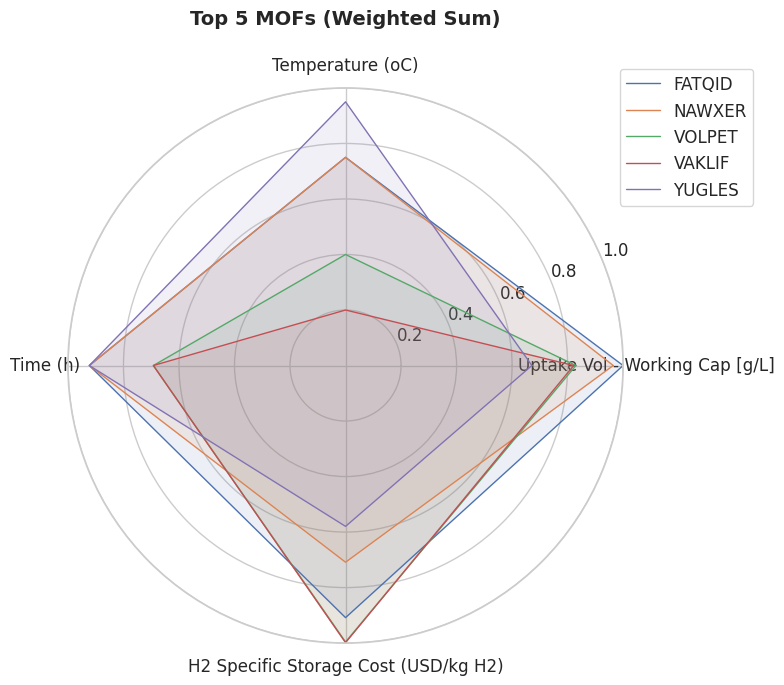

Saved: Top5_MOF_Weighted_Sum_Spider_Chart.png


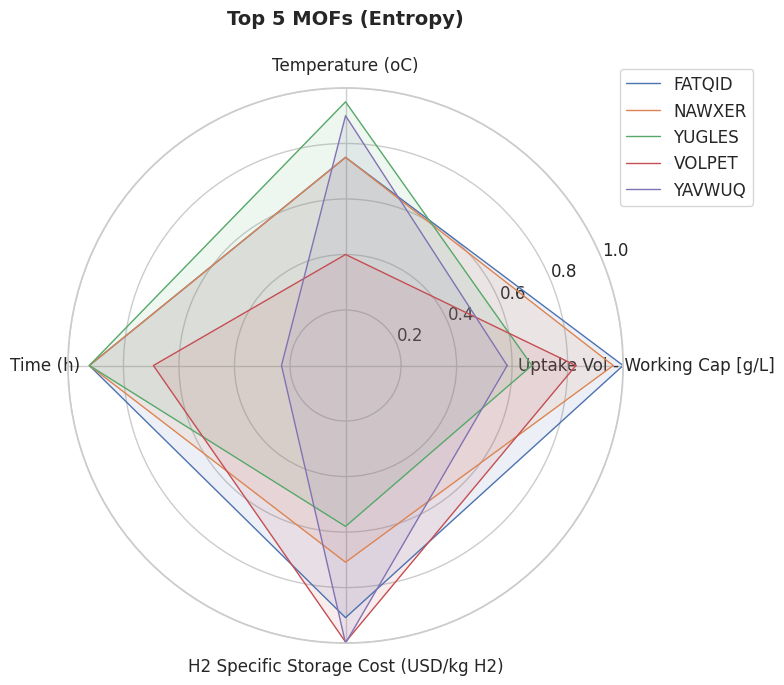

Saved: Top5_MOF_Entropy_Spider_Chart.png


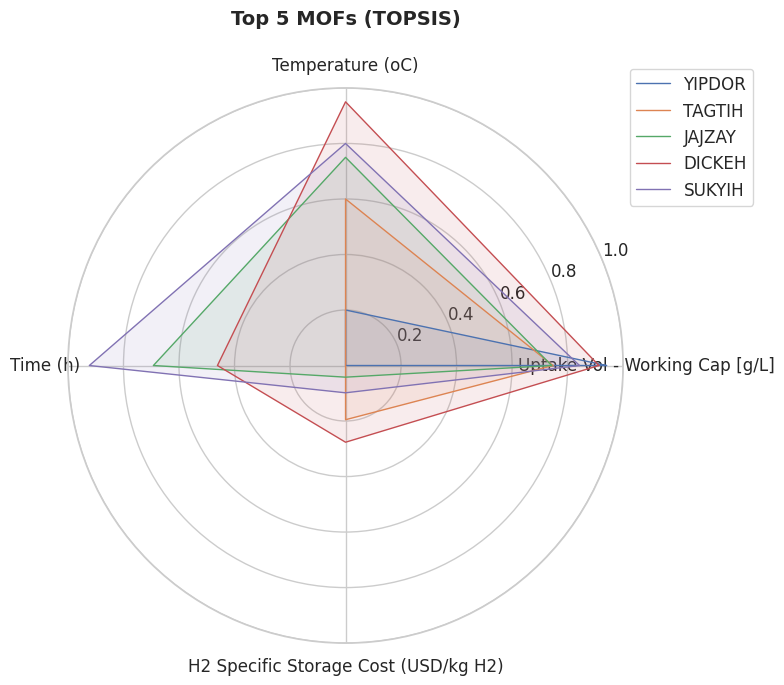

Saved: Top5_MOF_TOPSIS_Spider_Chart.png


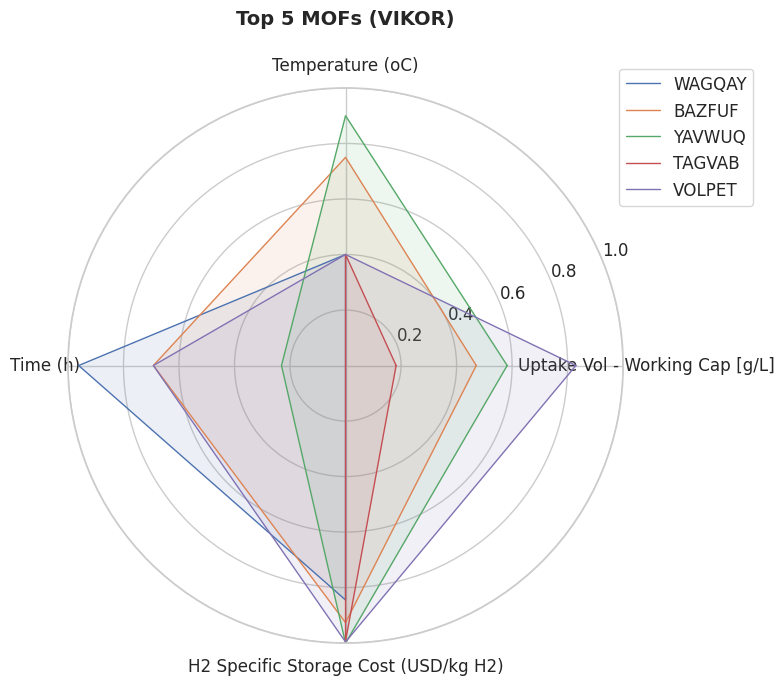

Saved: Top5_MOF_VIKOR_Spider_Chart.png


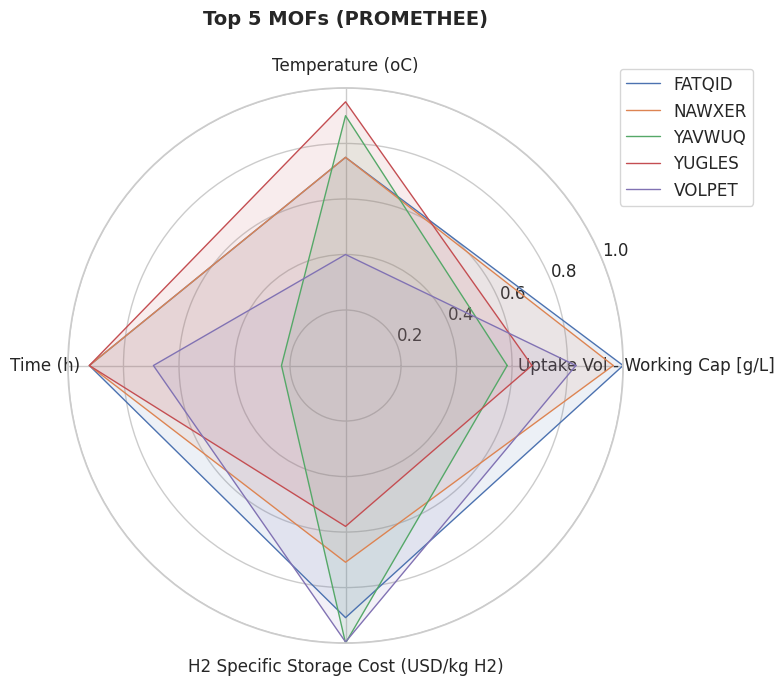

Saved: Top5_MOF_PROMETHEE_Spider_Chart.png

>>> Correlation analysis (Spearman & Kendall)


/tmp/ipython-input-144527017.py:191: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,Method1,Method2,SpearmanRho,KendallTau
0,Weighted Sum,Entropy,0.922277,0.777778
1,Weighted Sum,TOPSIS,-0.293377,-0.206349
2,Weighted Sum,VIKOR,0.471812,0.354497
3,Weighted Sum,PROMETHEE,0.866995,0.682540
4,Entropy,TOPSIS,-0.030651,-0.026455
5,Entropy,VIKOR,0.222222,0.174603
6,Entropy,PROMETHEE,0.957307,0.841270
7,TOPSIS,VIKOR,-0.877395,-0.735450
8,TOPSIS,PROMETHEE,0.047619,0.037037
9,VIKOR,PROMETHEE,0.160920,0.121693


=== STEP 4: Correlation Between MCDM Methods ===


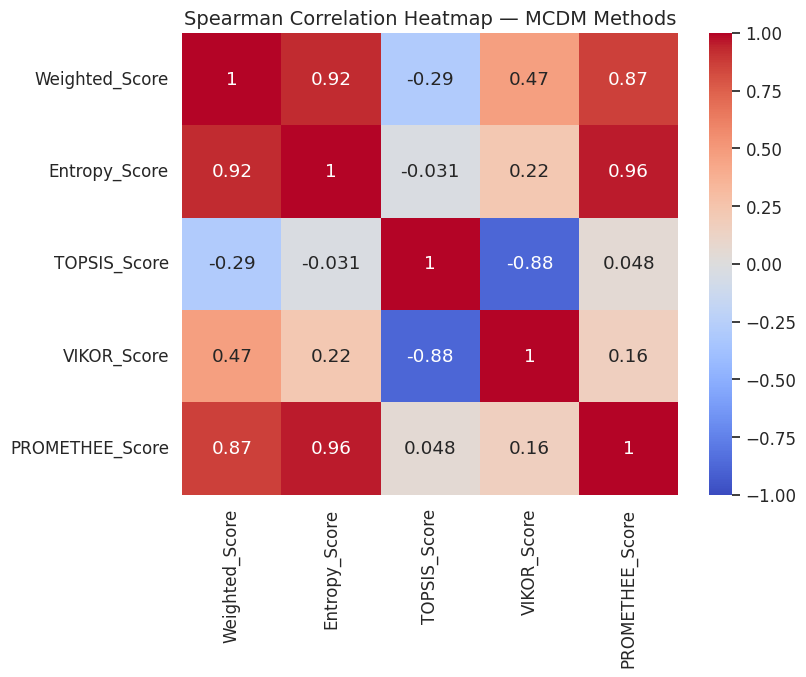

=== STEP 3: Histogram of MOF Parameters with Mean & Spearman Correlation ===


/tmp/ipython-input-144527017.py:211: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



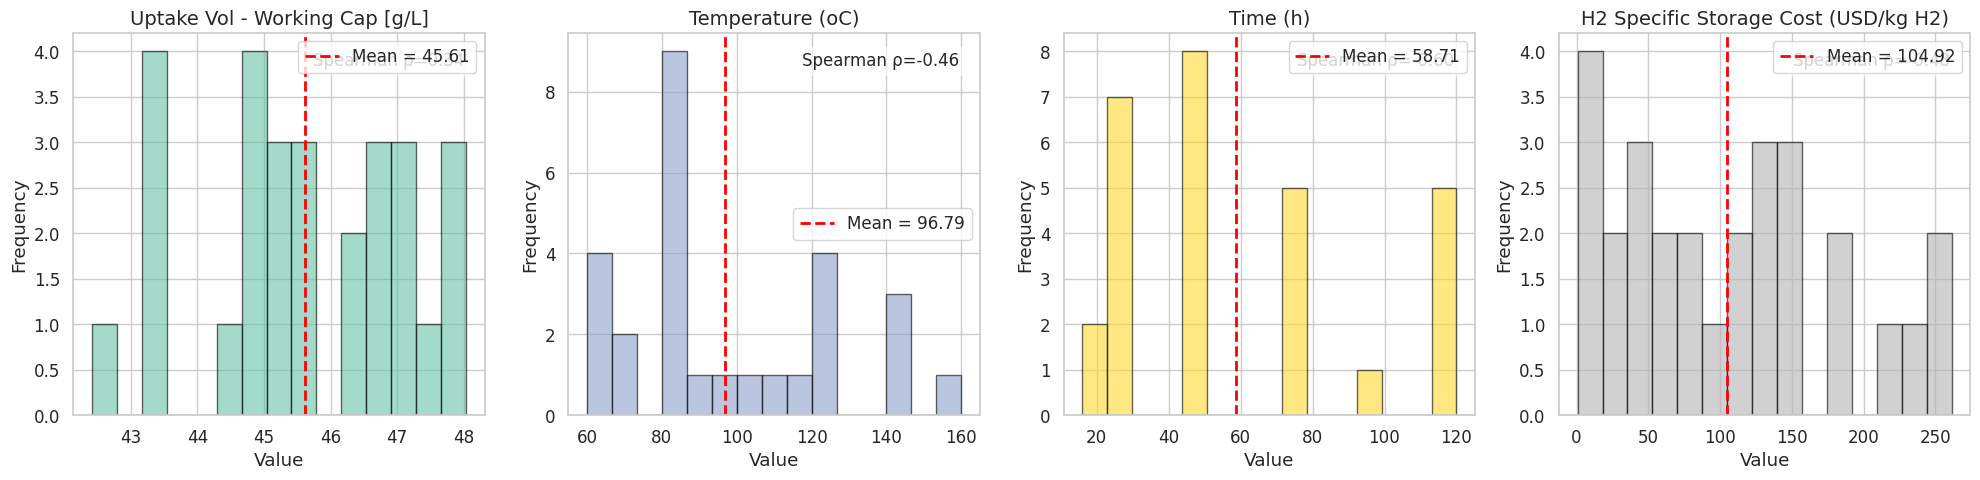


>>> Borda count consensus ranking


,MOF_Name,Consensus_Borda_Score,Consensus_Borda_Rank,Weighted_Score,Entropy_Score,TOPSIS_Score,VIKOR_Score,PROMETHEE_Score
9,FATQID,122.0,1.0,0.915059,0.898895,0.440055,0.812572,0.626223
8,NAWXER,115.0,2.0,0.833659,0.836468,0.482551,0.666118,0.470232
19,VOLPET,110.0,3.0,0.798277,0.736890,0.411562,0.848109,0.279941
26,YAVWUQ,106.0,4.0,0.701643,0.725846,0.375212,0.878224,0.384940
18,YUGLES,104.0,5.0,0.732285,0.757642,0.435386,0.637097,0.359614
14,VAKLIF,101.0,6.0,0.768322,0.680750,0.419351,0.833699,0.203158
10,NUBPIL,92.0,7.0,0.663309,0.702560,0.536805,0.510284,0.239679
1,BAZFUF,92.0,7.0,0.720860,0.691160,0.285376,0.889741,0.138644
4,DICKEH,87.0,9.0,0.594378,0.701444,0.671563,0.357414,0.272689
7,SUKYIH,83.0,10.0,0.588120,0.654586,0.639165,0.472322,0.241678


=== STEP 5: Borda Count Consensus Ranking ===


/tmp/ipython-input-144527017.py:253: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




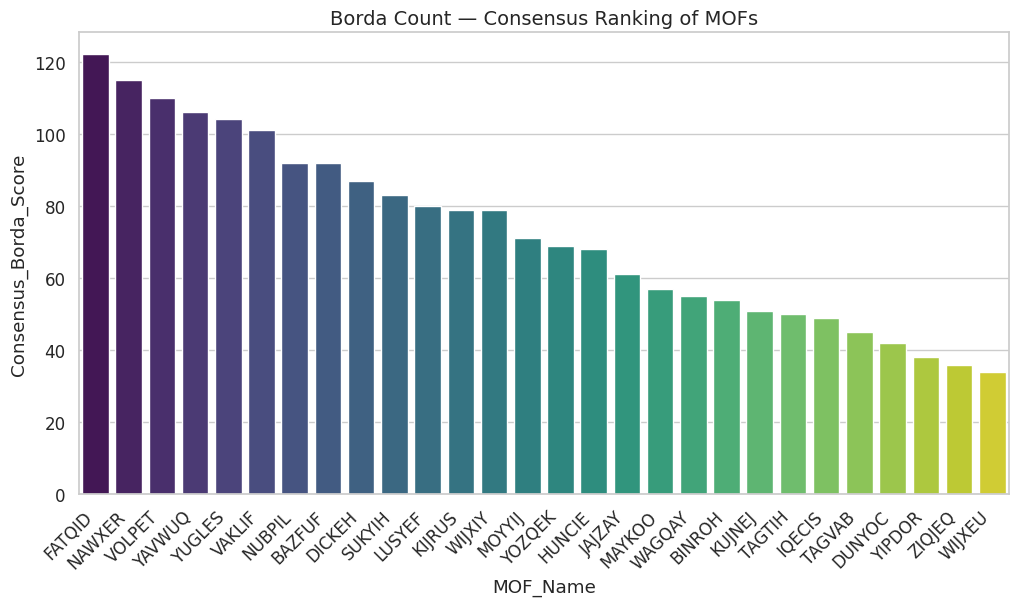


>>> Stability of Top-5 across methods


,MOF_Name,Top5_Frequency
0,VOLPET,4
1,FATQID,3
2,NAWXER,3
3,YUGLES,3
4,YAVWUQ,3
5,VAKLIF,1
6,YIPDOR,1
7,TAGTIH,1
8,JAJZAY,1
9,DICKEH,1


=== STEP 6: Top 5 MOF Stability Across Methods ===


/tmp/ipython-input-144527017.py:281: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




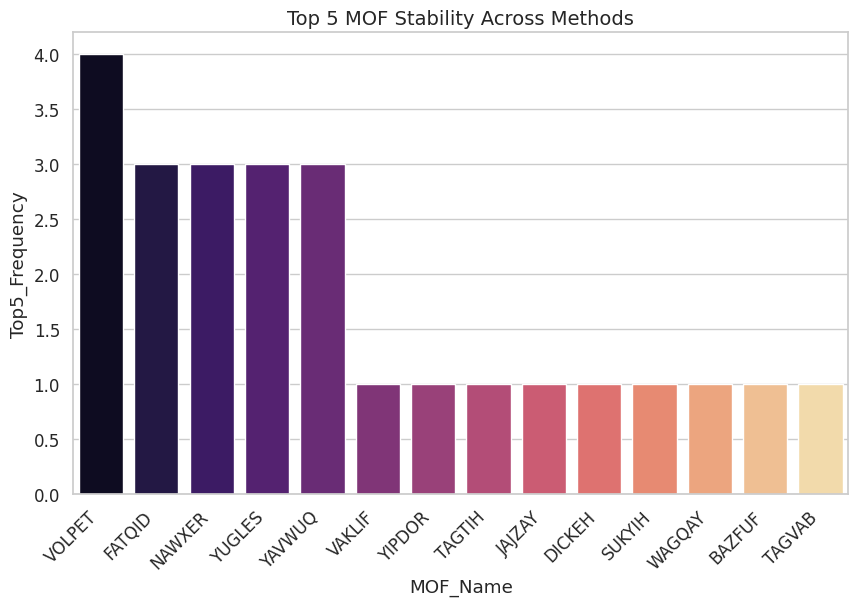


>>> Spider chart for consensus Top-5


/tmp/ipython-input-144527017.py:295: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



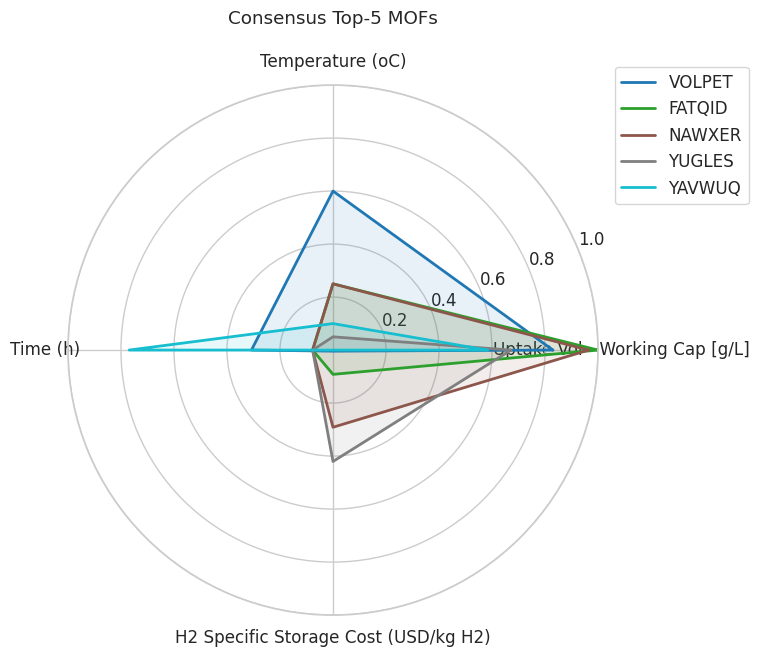

=== STEP 8: Heatmap of Top 5 MOFs Method Scores ===


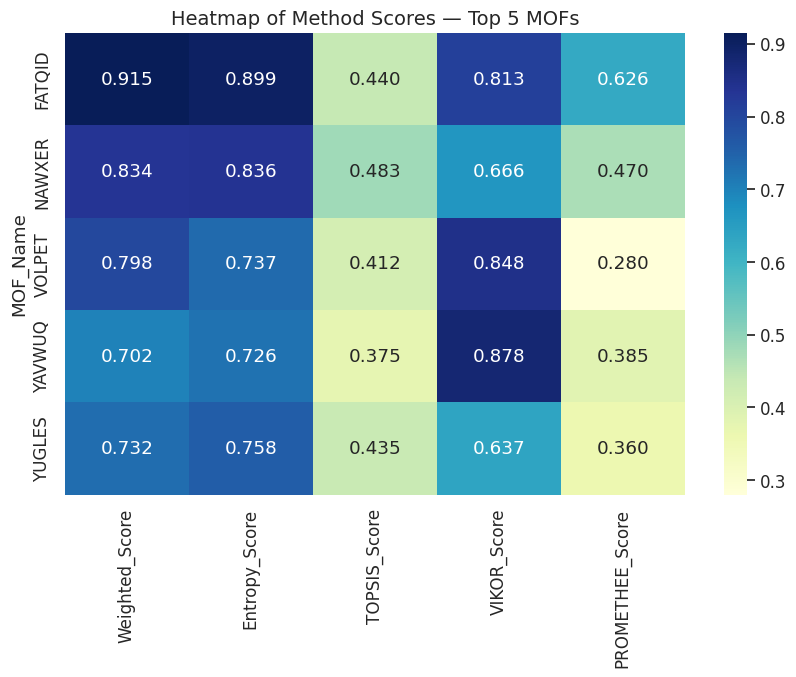


>>> Detailed view of Top-5


,MOF_Name,Uptake Vol - Working Cap [g/L],Temperature (oC),Time (h),H2 Specific Storage Cost (USD/kg H2),Weighted_Score,Entropy_Score,TOPSIS_Score,VIKOR_Score,PROMETHEE_Score,Consensus_Borda_Score,Consensus_Borda_Rank
9,FATQID,48.035145,85,24,24.621673,0.915059,0.898895,0.440055,0.812572,0.626223,122.0,1.0
8,NAWXER,47.835961,85,24,76.651305,0.833659,0.836468,0.482551,0.666118,0.470232,115.0,2.0
19,VOLPET,47.079913,120,48,1.771002,0.798277,0.736890,0.411562,0.848109,0.279941,110.0,3.0
26,YAVWUQ,45.689583,70,96,0.723633,0.701643,0.725846,0.375212,0.878224,0.384940,106.0,4.0
18,YUGLES,46.189314,65,24,110.328654,0.732285,0.757642,0.435386,0.637097,0.359614,104.0,5.0


Saved: Top5_MOF_Parameters_and_Scores.xlsx
✅ All tables saved — MOF_All_Methods_With_Consensus.xlsx, MOF_Top5_Stability.xlsx, Top5_MOF_Parameters_and_Scores.xlsx


In [ ]:
file_path = "Synthesis_Parameter_Screened.xlsx"
sheet_name = "Syn_Param_Screened"
output_table = "Top5_MOF_All_Methods.xlsx"
output_png = "Top5_MOF_All_Methods_Spider_Chart.png"

# Parameters used in scoring
PARAMETERS = [
    "Uptake Vol - Working Cap [g/L]",
    "Temperature (oC)",
    "Time (h)",
    "H2 Specific Storage Cost (USD/kg H2)"
]

cost_criteria = ["Temperature (oC)", "Time (h)", "H2 Specific Storage Cost (USD/kg H2)"]

# ================= LOAD DATA =================
df = pd.read_excel(file_path, sheet_name=sheet_name)
df.columns = df.columns.str.strip()
X = df[PARAMETERS].astype(float)
m, n = X.shape

print(">>> Loaded parameter data")
display(X)

# ================= NORMALIZATION =================
R = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
for p in PARAMETERS:
    col = X[p]
    min_val, max_val = col.min(), col.max()
    if max_val == min_val:
        R[p] = 1.0
    else:
        if p in cost_criteria:
            R[p] = (max_val - col) / (max_val - min_val)
        else:
            R[p] = (col - min_val) / (max_val - min_val)

R = R.replace(0, 1e-12)
print(">>> Normalized data (0–1 scale)")
display(R)

# ================= WEIGHTED SUM =================
weights_ws = np.array([0.286, 0.143, 0.214, 0.357])
df['Weighted_Score'] = (R.values @ weights_ws)
df['Weighted_Rank'] = df['Weighted_Score'].rank(ascending=False, method='min')
print(">>> Weighted Sum results")
display(df.sort_values('Weighted_Rank', ascending=True)[['MOF_Name','Weighted_Score','Weighted_Rank'] + PARAMETERS])

# ================= ENTROPY METHOD =================
k = 1 / np.log(m)
entropy = pd.Series(index=R.columns, dtype=float)
for p in R.columns:
    e_j = -k * ((R[p] * np.log(R[p])).sum())
    entropy[p] = e_j
d = 1 - entropy
w_entropy = d / d.sum()
df['Entropy_Score'] = (R * w_entropy.values).sum(axis=1)
df['Entropy_Rank'] = df['Entropy_Score'].rank(ascending=False, method='min')
print(">>> Entropy Method results")
display(df.sort_values('Entropy_Rank', ascending=True)[['MOF_Name','Entropy_Score','Entropy_Rank'] + PARAMETERS])

# ================= TOPSIS =================
w = np.array([4, 2, 3, 5], dtype=float)
w = w / w.sum()
R_norm = R / np.sqrt((R ** 2).sum(axis=0))
V = R_norm * w
ideal = pd.Series(index=R.columns, dtype=float)
anti_ideal = pd.Series(index=R.columns, dtype=float)
for j in R.columns:
    if j in cost_criteria:
        ideal[j] = V[j].min()
        anti_ideal[j] = V[j].max()
    else:
        ideal[j] = V[j].max()
        anti_ideal[j] = V[j].min()
D_pos = np.sqrt(((V - ideal) ** 2).sum(axis=1))
D_neg = np.sqrt(((V - anti_ideal) ** 2).sum(axis=1))

df['TOPSIS_Score'] = D_neg / (D_pos + D_neg)
df['TOPSIS_Rank'] = df['TOPSIS_Score'].rank(ascending=False, method='min')

print(">>> TOPSIS results")
display(df.sort_values('TOPSIS_Rank', ascending=True)[['MOF_Name','TOPSIS_Score','TOPSIS_Rank'] + PARAMETERS])

# ================= VIKOR =================
weights = np.array([0.286, 0.143, 0.214, 0.357], dtype=float)
f_star = pd.Series(index=R.columns, dtype=float)
f_minus = pd.Series(index=R.columns, dtype=float)
for j in R.columns:
    if j in cost_criteria:
        f_star[j] = R[j].min()
        f_minus[j] = R[j].max()
    else:
        f_star[j] = R[j].max()
        f_minus[j] = R[j].min()
epsilon = 1e-12
denominator = (f_star - f_minus).replace(0, epsilon)
normalized_diff = (f_star - R) / denominator
S = (weights * normalized_diff).sum(axis=1)
R_i = (weights * normalized_diff).max(axis=1)
v = 0.5

S_star, S_minus = S.min(), S.max()
R_star, R_minus = R_i.min(), R_i.max()

Q = v * (S - S_star) / (S_minus - S_star + epsilon) + \
    (1 - v) * (R_i - R_star) / (R_minus - R_star + epsilon)

df['VIKOR_Score'] = Q
df['VIKOR_Rank'] = df['VIKOR_Score'].rank(ascending=True, method='min')
print(">>> VIKOR results")
display(df.sort_values('VIKOR_Rank', ascending=True)[['MOF_Name','VIKOR_Score','VIKOR_Rank'] + PARAMETERS])

# ================= PROMETHEE =================
m = len(df)
w = w_entropy.values
def usual_preference(d):
    """Usual criterion: P(a,b) = 0 if d ≤ 0; 1 if d > 0."""
    return np.where(d > 0, 1, 0)
pi_matrix = pd.DataFrame(0.0, index=df.index, columns=df.index)

for i in df.index:
    for j in df.index:
        if i == j:
            continue
        pref_sum = 0
        for k_idx, p_name in enumerate(PARAMETERS):
            diff = R.loc[i, p_name] - R.loc[j, p_name]
            P_ij = usual_preference(diff)
            pref_sum += w[k_idx] * P_ij
        pi_matrix.loc[i, j] = pref_sum
phi_plus = pi_matrix.sum(axis=1) / (m - 1)
phi_minus = pi_matrix.sum(axis=0) / (m - 1)
phi_net = phi_plus - phi_minus

df['PROMETHEE_LeavingFlow'] = phi_plus
df['PROMETHEE_EnteringFlow'] = phi_minus
df['PROMETHEE_Score'] = phi_net
df['PROMETHEE_Rank'] = df['PROMETHEE_Score'].rank(ascending=False, method='min')

print(">>> PROMETHEE results")
display(df.sort_values('PROMETHEE_Rank', ascending=True)[['MOF_Name','PROMETHEE_LeavingFlow', 'PROMETHEE_EnteringFlow', 'PROMETHEE_Score', 'PROMETHEE_Rank'] + PARAMETERS])

# ================= TOP 5 COMPARISON =================
methods_rank = ['Weighted_Rank','Entropy_Rank','TOPSIS_Rank','VIKOR_Rank','PROMETHEE_Rank']
top5_compare = pd.DataFrame()
for method in methods_rank:
    top5_compare[method] = df.sort_values(by=method).head(5)['MOF_Name'].values
print(">>> Top 5 MOF comparison table")
display(top5_compare)
top5_compare.to_excel(output_table, index=False)
print(f"Saved: {output_table}")

# ================= SPIDER CHARTS =================
methods_score = ['Weighted_Score','Entropy_Score','TOPSIS_Score','VIKOR_Score','PROMETHEE_Score']
methods_name  = ['Weighted Sum','Entropy','TOPSIS','VIKOR','PROMETHEE']

for m_idx, method in enumerate(methods_score):
    top5_idx = df.sort_values(by=method, ascending=False).head(5).index
    norm_top5 = R.loc[top5_idx]

    labels = PARAMETERS
    num_vars = len(labels)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
    for idx in top5_idx:
        values = norm_top5.loc[idx].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, label=df.loc[idx,'MOF_Name'])
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, 1)
    ax.set_title(f"Top 5 MOFs ({methods_name[m_idx]})", y=1.1, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05))
    plt.tight_layout()
    png_file = f"Top5_MOF_{methods_name[m_idx].replace(' ','_')}_Spider_Chart.png"
    plt.savefig(png_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {png_file}")

# =================== CORRELATION ===================
print("\n>>> Correlation analysis (Spearman & Kendall)")
corr_table = pd.DataFrame(columns=['Method1','Method2','SpearmanRho','KendallTau'])
for i in range(len(methods_score)):
    for j in range(i+1,len(methods_score)):
        rho, _ = spearmanr(df[methods_score[i]], df[methods_score[j]])
        tau, _ = kendalltau(df[methods_score[i]], df[methods_score[j]])
        corr_table = pd.concat([corr_table,pd.DataFrame({
            'Method1':[methods_name[i]],
            'Method2':[methods_name[j]],
            'SpearmanRho':[rho],
            'KendallTau':[tau]
        })], ignore_index=True)
display(corr_table)

## =================== CORRELATION BETWEEN METHODS (HEATMAP) ===================
print("=== STEP 4: Correlation Between MCDM Methods ===")
corr_matrix = df[methods_score].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap — MCDM Methods", fontsize=14)
plt.show()

## =================== HISTOGRAM OF PARAMETERS WITH MEAN & SPEARMAN ===================
print("=== STEP 3: Histogram of MOF Parameters with Mean & Spearman Correlation ===")
n_params = len(PARAMETERS)
fig, axes = plt.subplots(1, n_params, figsize=(5*n_params,5))
colors = cm.get_cmap('Set2', n_params)

for idx, p in enumerate(PARAMETERS):
    ax = axes[idx]
    data = df[p]

    # Histogram
    ax.hist(data, bins=15, alpha=0.6, color=colors(idx), edgecolor='black')

    # Mean line
    mean_val = data.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')

    # Spearman correlation with Weighted_Score
    rho, _ = spearmanr(data, df['Weighted_Score'])
    ax.text(0.95, 0.95, f'Spearman ρ={rho:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    ax.set_title(p, fontsize=14)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

# =================== BORDA COUNT ===================
print("\n>>> Borda count consensus ranking")
rank_df = df[methods_score].rank(ascending=False, method='min')
borda_scores = (len(df)-rank_df+1).sum(axis=1)
df['Consensus_Borda_Score'] = borda_scores
df['Consensus_Borda_Rank'] = borda_scores.rank(ascending=False, method='min')
display(df.sort_values('Consensus_Borda_Rank', ascending=True)[['MOF_Name','Consensus_Borda_Score','Consensus_Borda_Rank'] + methods_score])

## =================== BORDA COUNT CONSENSUS ===================
print("=== STEP 5: Borda Count Consensus Ranking ===")
rank_df = df[methods_score].rank(ascending=False, method='min')
borda_scores = (len(df)-rank_df+1).sum(axis=1)
df['Consensus_Borda_Score'] = borda_scores
df['Consensus_Borda_Rank'] = borda_scores.rank(ascending=False, method='min')

plt.figure(figsize=(12,6))
sns.barplot(x='MOF_Name', y='Consensus_Borda_Score', data=df.sort_values('Consensus_Borda_Rank'), palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Borda Count — Consensus Ranking of MOFs", fontsize=14)
plt.show()


# =================== TOP 5 STABILITY ===================
print("\n>>> Stability of Top-5 across methods")
top5_dict = {}
for method in methods_score:
    top5_dict[method] = df.sort_values(by=method, ascending=False).head(5)['MOF_Name'].tolist()
top5_flat = [mof for sublist in top5_dict.values() for mof in sublist]
stability_count = pd.Series(top5_flat).value_counts()
stability_table = pd.DataFrame({'MOF_Name':stability_count.index,'Top5_Frequency':stability_count.values})
stability_table = stability_table.sort_values(by='Top5_Frequency', ascending=False)
display(stability_table)

## =================== TOP 5 STABILITY ACROSS METHODS (BAR CHART) ===================
print("=== STEP 6: Top 5 MOF Stability Across Methods ===")
top5_dict = {}
for method in methods_score:
    top5_dict[method] = df.sort_values(by=method, ascending=False).head(5)['MOF_Name'].tolist()
top5_flat = [mof for sublist in top5_dict.values() for mof in sublist]
stability_count = pd.Series(top5_flat).value_counts()
stability_table = pd.DataFrame({'MOF_Name':stability_count.index,'Top5_Frequency':stability_count.values})
stability_table = stability_table.sort_values(by='Top5_Frequency', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='MOF_Name', y='Top5_Frequency', data=stability_table, palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Top 5 MOF Stability Across Methods", fontsize=14)
plt.show()

# =================== SPIDER CHART ===================
print("\n>>> Spider chart for consensus Top-5")
top5_most_stable = stability_table.head(5)['MOF_Name'].tolist()
norm_params = df[PARAMETERS].copy()
norm_params = (norm_params - norm_params.min())/(norm_params.max()-norm_params.min())
angles = np.linspace(0,2*np.pi,len(PARAMETERS),endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
colors = cm.get_cmap('tab10',5)
for idx,mof in enumerate(top5_most_stable):
    values = norm_params[df['MOF_Name']==mof].iloc[0].tolist()
    values += values[:1]
    ax.plot(angles,values,linewidth=2,label=mof,color=colors(idx))
    ax.fill(angles,values,alpha=0.1,facecolor=colors(idx))
ax.set_thetagrids(np.degrees(angles[:-1]),PARAMETERS)
ax.set_ylim(0,1)
ax.set_title("Consensus Top-5 MOFs", y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.05))
plt.tight_layout()
plt.show()

## =================== HEATMAP OF TOP 5 MOF METHOD SCORES ===================
print("=== STEP 8: Heatmap of Top 5 MOFs Method Scores ===")
top5_idx = df.sort_values('Consensus_Borda_Rank').head(5).index
top5_detailed = df.loc[top5_idx, ['MOF_Name'] + methods_score]

plt.figure(figsize=(10,6))
sns.heatmap(top5_detailed.set_index('MOF_Name'), annot=True, cmap='YlGnBu', fmt=".3f")
plt.title("Heatmap of Method Scores — Top 5 MOFs", fontsize=14)
plt.show()

# =================== TOP 5 DETAILED ===================
print("\n>>> Detailed view of Top-5")
top5_idx = df.sort_values('Consensus_Borda_Rank').head(5).index
top5_detailed = df.loc[top5_idx, ['MOF_Name'] + PARAMETERS + methods_score + ['Consensus_Borda_Score','Consensus_Borda_Rank']]
display(top5_detailed)
top5_detailed.to_excel("Top5_MOF_Parameters_and_Scores.xlsx", index=False)
print("Saved: Top5_MOF_Parameters_and_Scores.xlsx")


# =================== SAVE TABLES ===================
df.to_excel("MOF_All_Methods_With_Consensus.xlsx", index=False)
stability_table.to_excel("MOF_Top5_Stability.xlsx", index=False)
top5_detailed.to_excel("Top5_MOF_Parameters_and_Scores.xlsx", index=False)
print("✅ All tables saved — MOF_All_Methods_With_Consensus.xlsx, MOF_Top5_Stability.xlsx, Top5_MOF_Parameters_and_Scores.xlsx")

7. Visualisasi Hasil MCDM

In [ ]:
# peta konsensus hasil MCDM:skor rata-rata metode vs skor konsensus borda
MCDM_COLORS = FILL_COLORS

def mcdm_layout(title, x_title, y_title):
    return dict(
        title=dict(text=title, x=0.5),
        xaxis=dict(title=x_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        yaxis=dict(title=y_title, showline=True, linewidth=2, linecolor="black", mirror=True),
        font=dict(family="Arial", size=14),
        width=800,
        height=600,
        plot_bgcolor="white",
        paper_bgcolor="white",
    )

methods_score = ['Weighted_Score', 'Entropy_Score', 'TOPSIS_Score', 'VIKOR_Score', 'PROMETHEE_Score']
if 'Top5_Frequency' not in df.columns:
    df = df.merge(stability_table[['MOF_Name', 'Top5_Frequency']], on='MOF_Name', how='left')
df['Top5_Frequency'] = df['Top5_Frequency'].fillna(0).astype(int)
df['Avg_Method_Score'] = df[methods_score].mean(axis=1)
top5_cutoff = df.nlargest(5, 'Consensus_Borda_Score')['Consensus_Borda_Score'].min()
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df['Consensus_Borda_Score'],
        y=df['Avg_Method_Score'],
        mode="markers",
        marker=dict(
            size=20 + df['Top5_Frequency'] * 7,
            color=df['Top5_Frequency'],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Frekuensi Top-5",
                titleside="right",
                tickfont=dict(size=12),
                titlefont=dict(size=14)
            ),
            line=dict(color="black", width=1),
            opacity=0.85,
        ),
        text=df['MOF_Name'],
        name="MOF"
    )
)
fig.add_vline(
    x=top5_cutoff,
    line=dict(color="black", width=2, dash="dash"),
    annotation_text="Batas Top-5",
    annotation_position="top"
)
layout = mcdm_layout(
    "Peta Konsensus",
    "Skor Konsensus Borda",
    "Skor Rata-Rata MCDM"
)
layout["xaxis"]["dtick"] = 10
layout["xaxis"]["tick0"] = 0
fig.update_layout(**layout)
fig.update_xaxes(
    ticks="outside",
    ticklen=8,
    tickwidth=2,
    showline=True,
    linecolor="black",
    mirror=True
)
fig.update_yaxes(
    ticks="outside",
    ticklen=8,
    tickwidth=2,
    showline=True,
    linecolor="black",
    mirror=True
)
fig.show()


# koordinat paralel 5 MOF terbaik
from pandas.plotting import parallel_coordinates
top5 = df.sort_values('Consensus_Borda_Rank').head(5).copy()
cols_for_parallel = PARAMETERS + ['Consensus_Borda_Rank', 'MOF_Name']
top5_scaled = top5.copy()
min_max_dict = {}
for p in PARAMETERS:
    min_val = df[p].min()
    max_val = df[p].max()
    min_max_dict[p] = (min_val, max_val)
    if max_val != min_val:
        top5_scaled[p] = (top5[p] - min_val) / (max_val - min_val)
    else:
        top5_scaled[p] = 0.5
rank_min, rank_max = df['Consensus_Borda_Rank'].min(), df['Consensus_Borda_Rank'].max()
top5_scaled['Consensus_Borda_Rank'] = 1 - (top5['Consensus_Borda_Rank'] - rank_min) / (rank_max - rank_min)
top5_scaled[PARAMETERS + ['Consensus_Borda_Rank']] = top5_scaled[PARAMETERS + ['Consensus_Borda_Rank']].astype(float)
plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", len(top5_scaled))
dims = []
for p in PARAMETERS:
    dims.append(dict(
        label=f"{p}",
        values=top5_scaled[p],
        tickvals=[],
        ticktext=[]
    ))
dims.append(dict(
    label="Consensus_Borda_Rank (norm)",
    values=top5_scaled['Consensus_Borda_Rank'],
    tickvals=[],
    ticktext=[]
))
dims = []
for p in PARAMETERS:
    dims.append(dict(
        label=f"{p}",
        values=top5_scaled[p],
        tickformat=".2f"
    ))
dims.append(dict(
    label="Consensus_Borda_Rank (norm)",
    values=top5_scaled['Consensus_Borda_Rank'],
    tickformat=".2f"
))
fig = go.Figure(
    data=go.Parcoords(
        line=dict(
            color=list(range(len(top5_scaled))),
            colorscale=MCDM_COLORS
        ),
        dimensions=dims,
        labelfont=dict(size=12),
        tickfont=dict(size=11)
    )
)
for i, mof in enumerate(top5['MOF_Name']):
    fig.add_trace(
        go.Scatter(
            x=[None], y=[None],
            mode="lines",
            line=dict(color=MCDM_COLORS[i % len(MCDM_COLORS)], width=4),
            name=mof,
            showlegend=True
        )
    )
layout_pc = mcdm_layout(
    "Koordinat Paralel — 5 MOF Terbaik",
    "", "Nilai Ternormalisasi (0–1)"
)
layout_pc["width"]  = 1000
layout_pc["height"] = 600
fig.update_layout(**layout_pc)
fig.show()


# diagram radar 5 MOF terbaik berdasarkan seluruh metode MCDM
top5_consensus = df.sort_values('Consensus_Borda_Rank').head(5)['MOF_Name'].tolist()
methods_data = df.loc[
    df['MOF_Name'].isin(top5_consensus),
    methods_score + ['MOF_Name']
].set_index('MOF_Name')
methods_norm = (methods_data - methods_data.min()) / (methods_data.max() - methods_data.min())
labels = methods_name
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
colors = sns.color_palette("husl", len(top5_consensus))
sns.set_style("white")

fig = go.Figure()
for i, mof in enumerate(methods_norm.index):
    values = methods_norm.loc[mof].tolist()
    values += values[:1]
    fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=labels + [labels[0]],
            fill="toself",
            name=mof,
            line=dict(width=2, color=MCDM_COLORS[i % len(MCDM_COLORS)])
        )
    )
fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], gridcolor="#DDDDDD"),
    ),
    showlegend=True,
    **mcdm_layout(
        "Diagram Radar — 5 MOF Terbaik",
        "", ""
    )
)
fig.show()

<Figure size 1000x600 with 0 Axes>

8. Ekstraksi Parameter Sintesis 5 MOF Terbaik

In [ ]:
# Ekstraksi parameter sintesis 5 MOF terbaik
synthesis_columns = [
    'MOF_Name',
    'Temperature (oC)',
    'Time (h)',
    'Solvent_Name',
    'Additive_Name',
    'Modulator_Name',
    'Metal_Name',
    'Linker1_Name',
    'Linker2_Name'
]

# pengecekan kolom yang tersedia dalam dataframe
existing_cols = [col for col in synthesis_columns if col in df.columns]
missing_cols = set(synthesis_columns) - set(existing_cols)
if missing_cols:
    print(f"[Warning] Missing columns in dataframe: {missing_cols}")

# 5 MOF teratas ditentukan berdasarkan peringkat konsensus borda
top5_idx = df.sort_values('Consensus_Borda_Rank').head(5).index
top5_synthesis = df.loc[top5_idx, existing_cols]

display(top5_synthesis)
top5_synthesis.to_excel("Top5_MOF_Synthesis_Info.xlsx", index=False)
print("[OK] File saved: Top5_MOF_Synthesis_Info.xlsx")


,MOF_Name,Temperature (oC),Time (h),Solvent_Name,Additive_Name,Modulator_Name,Metal_Name,Linker1_Name,Linker2_Name
9,FATQID,85,24,DMF,0,HNO3,CuSO₄·5H₂O,H₂L,0
8,NAWXER,85,24,DMF,EtOH,HNO3,Zn(NO₃)₂·6H₂O,H4TCPP,0
19,VOLPET,120,48,DMF,MeCN,0,Zn(NO₃)₂·6H₂O,H₂thb,0
26,YAVWUQ,70,96,DMF,0,HCl,Cu(NO₃)₂·2.5H₂O,H4L,0
18,YUGLES,65,24,DMF,DMSO,HNO3,Cu(NO₃)₂·3H₂O,H₄EBTC,0


[OK] File saved: Top5_MOF_Synthesis_Info.xlsx


9. Estimasi Kapasitas Panas Linker

In [ ]:
# Inisialisasi dan pemeriksaan rdkit
USE_RDKIT = True
try:
    from rdkit import Chem
except Exception:
    USE_RDKIT = False
    print("[WARN] RDKit not available. Using fallback string matching.")
print(f"[OK] Setup complete. USE_RDKIT = {USE_RDKIT}")

# Definisi grup joback untuk estimasi kapasitas panas
print("\n>>> Defining extended Joback Cp groups for RDKit")
JOBACK_CP_GROUPS = {
    # --- Non-ring increments ---
    "CH3":   {"smarts": "[CH3X4]", "a": 1.95E+01, "b": -8.08E-03, "c": 1.53E-04, "d": -9.67E-08},
    "CH2":   {"smarts": "[CH2X4]", "a": -9.09E-01, "b": 9.50E-02, "c": -5.44E-05, "d": 1.19E-08},
    "CH":    {"smarts": "[CHX4]",  "a": -2.30E+01, "b": 2.04E-01, "c": -2.65E-04, "d": 1.20E-07},
    "C":     {"smarts": "[CX4]",   "a": -6.62E+01, "b": 4.27E-01, "c": -6.41E-04, "d": 3.01E-07},
    "CH2=":  {"smarts": "[CH2]=[CX3]", "a": 2.36E+01, "b": -3.81E-02, "c": 1.72E-04, "d": -1.03E-07},
    "CH=":   {"smarts": "[CH]=[CX3]",  "a": -8.00E+00, "b": 1.05E-01, "c": -9.63E-05, "d": 3.56E-08},
    "C=":    {"smarts": "[CX3]=[CX3]", "a": -2.81E+01, "b": 2.08E-01, "c": -3.06E-04, "d": 1.46E-07},
    "C=C":   {"smarts": "[CX3]=[CX3]", "a": 2.74E+01, "b": -5.57E-02, "c": 1.01E-04, "d": -5.02E-08},
    "C#C":   {"smarts": "[CX2]#C",     "a": 7.87E+00, "b": 2.01E-02, "c": -8.33E-06, "d": 1.39E-09},
    # --- Ring increments ---
    "ring_CH2": {"smarts": "[CH2R0]", "a": -6.03E+00, "b": 8.54E-02, "c": -8.00E-06, "d": -1.80E-08},
    "ring_CH":  {"smarts": "[CHR0]",  "a": -2.05E+01, "b": 1.62E-01, "c": -1.60E-04, "d": 6.24E-08},
    "ring_C":   {"smarts": "[CR0X4]", "a": -9.09E+01, "b": 5.57E-01, "c": -9.00E-04, "d": 4.69E-07},
    "ring_cH":  {"smarts": "[cH]",    "a": -2.14E+00, "b": 5.74E-02, "c": -1.64E-06, "d": -1.59E-08},
    "ring_c":   {"smarts": "[c]",     "a": -8.25E+00, "b": 1.01E-01, "c": -1.42E-04, "d": 6.78E-08},
    # --- Halogen increments ---
    "F":  {"smarts": "[F]",  "a": 2.65E+01, "b": -9.13E-02, "c": 1.91E-04, "d": -1.03E-07},
    "Cl": {"smarts": "[Cl]", "a": 3.33E+01, "b": -9.63E-02, "c": 1.87E-04, "d": -9.96E-08},
    "Br": {"smarts": "[Br]", "a": 2.86E+01, "b": -6.49E-02, "c": 1.36E-04, "d": -7.45E-08},
    "I":  {"smarts": "[I]",  "a": 3.21E+01, "b": -6.41E-02, "c": 1.26E-04, "d": -6.87E-08},
    # --- Oxygen increments ---
    "OH_alcohol": {"smarts": "[OX2H]", "a": 2.57E+01, "b": -6.91E-02, "c": 1.77E-04, "d": -9.88E-08},
    "OH_phenol":  {"smarts": "[cOX2H]", "a": -2.81E+00, "b": 1.11E-01, "c": -1.16E-04, "d": 4.94E-08},
    "O_nonring":  {"smarts": "[OX2]", "a": 2.55E+01, "b": -6.32E-02, "c": 1.11E-04, "d": -5.48E-08},
    "O_ring":     {"smarts": "[OX2R0]", "a": 1.22E+01, "b": -1.26E-02, "c": 6.03E-05, "d": -3.86E-08},
    "CO_nonring": {"smarts": "[CX3]=[OX1]", "a": 6.45E+00, "b": 6.70E-02, "c": -3.57E-05, "d": 2.86E-09},
    "CO_ring":    {"smarts": "[CX3R]=[OX1]", "a": 3.04E+01, "b": -8.29E-02, "c": 2.36E-04, "d": -1.31E-07},
    "CHO":        {"smarts": "[CH]=[OX1]", "a": 3.09E+01, "b": -3.36E-02, "c": 1.60E-04, "d": -9.88E-08},
    "COOH":       {"smarts": "[CX3](=O)[OX2H1]", "a": 2.41E+01, "b": 4.27E-02, "c": 8.04E-05, "d": -6.87E-08},
    "COOR":       {"smarts": "[CX3](=O)[OX2]", "a": 2.45E+01, "b": 4.02E-02, "c": 4.02E-05, "d": -4.52E-08},
    "C=O_other":  {"smarts": "[OX1]=[CX3]", "a": 6.82E+00, "b": 1.96E-02, "c": 1.27E-05, "d": -1.78E-08},
    # --- Nitrogen increments ---
    "NH2":        {"smarts": "[NX3H2]", "a": 2.69E+01, "b": -4.12E-02, "c": 1.64E-04, "d": -9.76E-08},
    "NH_nonring": {"smarts": "[NX3H]", "a": -1.21E+00, "b": 7.62E-02, "c": -4.86E-05, "d": 1.05E-08},
    "NH_ring":    {"smarts": "[NX3H;R]", "a": 1.18E+01, "b": -2.30E-02, "c": 1.07E-04, "d": -6.28E-08},
    "N_nonring":  {"smarts": "[NX3]", "a": -3.11E+01, "b": 2.27E-01, "c": -3.20E-04, "d": 1.46E-07},
    "N=_nonring": {"smarts": "[NX2]=[CX3]", "a": 0.00E+00, "b": 0.00E+00, "c": 0.00E+00, "d": 0.00E+00},
    "N=_ring":    {"smarts": "[NX2;R]=[CX3]", "a": 8.83E+00, "b": -3.84E-03, "c": 4.35E-05, "d": -2.60E-08},
    "NH=":        {"smarts": "[NH]=[CX3]", "a": 5.69E+00, "b": -4.12E-03, "c": 1.28E-04, "d": -8.88E-08},
    "CN":         {"smarts": "[CX2]#N", "a": 3.65E+01, "b": -7.33E-02, "c": 1.84E-04, "d": -1.03E-07},
    "NO2":        {"smarts": "[N+](=O)[O-]", "a": 2.59E+01, "b": -3.74E-03, "c": 1.29E-04, "d": -8.88E-08},
    # --- Sulfur increments ---
    "SH":         {"smarts": "[SX2H1]", "a": 3.53E+01, "b": -7.58E-02, "c": 1.85E-04, "d": -1.03E-07},
    "S_nonring":  {"smarts": "[SX2]", "a": 1.96E+01, "b": -5.61E-03, "c": 4.02E-05, "d": -2.76E-08},
    "S_ring":     {"smarts": "[SX2;R]", "a": 1.67E+01, "b": 4.81E-03, "c": 2.77E-05, "d": -2.11E-08},
}
print(f"[OK] {len(JOBACK_CP_GROUPS)} Joback Cp groups defined successfully")

# Manual Cp override untuk top 5 MOF
smiles_list = [
    "C(=O)(O)C1=CC=C(C=C1)C=1C=NC=C(C1)C1=CC=C(C=C1)C(=O)O",
    "C(=O)(O)C1=CC=C(C=C1)C=1C(=NC(=C(N1)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C=C1)C(=O)O)C1=CC=C(C(=O)O)C=C1",
    "S1C(=CC=C1C(=O)O)C(=O)O",
    "C(=O)O",
    "N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C=C(C1)C(=O)O)C(=O)O",
    "C(#CC=1C=C(C=C(C(=O)O)C1)C(=O)O)C=1C=C(C=C(C(=O)O)C1)C(=O)O"
]
Cp_list = [
    364.47,
    586.17,
    181.99,
    41.29,
    387.69,
    345.59
]
# dictionary: SMILES -> Cp manual
MANUAL_CP_MAP = dict(zip(smiles_list, Cp_list))
# fungsi bantu untuk estimasi cp
print("\n>>> Defining helper functions")
USE_RDKIT = True
def _naive_counts(smiles):
    """fungsi cadangan jika rdkit gagal membaca struktur"""
    s = str(smiles) if pd.notna(smiles) else ""
    return {g: 0 for g in JOBACK_CP_GROUPS.keys()}

def count_groups_from_smiles(smiles):
    """fungsi untuk menghitung jumlah tiap grup joback berdasarkan pola SMARTS"""
    if not USE_RDKIT:
        return _naive_counts(smiles)
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return _naive_counts(smiles)
        counts = {}
        for g, info in JOBACK_CP_GROUPS.items():
            patt = Chem.MolFromSmarts(info["smarts"])
            matches = mol.GetSubstructMatches(patt)
            counts[g] = len(matches)
        return counts
    except Exception:
        return _naive_counts(smiles)

def joback_Cp_from_counts(counts, T_K):
    """fungsi untuk menghitung kapasitas panas total (Cp) dari jumlah grup"""
    Cp = 0.0
    for g, n in counts.items():
        if g in JOBACK_CP_GROUPS:
            a, b, c, d = JOBACK_CP_GROUPS[g]["a"], JOBACK_CP_GROUPS[g]["b"], JOBACK_CP_GROUPS[g]["c"], JOBACK_CP_GROUPS[g]["d"]
            Cp += n * (a - 37.93 + (b +0.21)* T_K + (c-3.91E-04) * T_K**2 + (d+(2.06*1E-07)) * T_K**3)
    return Cp

def estimate_joback_from_smiles(smiles, T_for_Cp=298.15):
    """fungsi untuk estimasi Cp, dengan prioritas ke nilai manual jika tersedia"""
    if smiles in MANUAL_CP_MAP:
        return {
            "Cp_J_per_molK": MANUAL_CP_MAP[smiles],
            "counts": None,
            "source": "manual"
        }
    counts = count_groups_from_smiles(smiles)
    Cp = joback_Cp_from_counts(counts, T_for_Cp)
    return {
        "Cp_J_per_molK": Cp,
        "counts": counts,
        "source": "joback"
    }
print("[OK] Utility functions ready")

# Pemuatan dataset sintesis
print("\n>>> Loading synthesis dataset")
full_synth_file = Synthesis_Parameter
full_df = pd.read_excel(full_synth_file)
display(full_df.head())

# Pemuatan data 5 MOF terbaik
print("\n>>> Loading top 5 MOF names")
top5_file = "Top5_MOF_Synthesis_Info.xlsx"
top5_info = pd.read_excel(top5_file)
top5_mof_names = top5_info['MOF_Name'].tolist()
print(f"[OK] Top 5 MOFs: {top5_mof_names}")
print("\n>>> Checking manual SMILES match with Top 5 MOFs")

top5_df = full_df[full_df['MOF_Name'].isin(top5_mof_names)]
top5_smiles = set(top5_df['SMILES1'].dropna().tolist() +
                  top5_df['SMILES2'].dropna().tolist())
manual_smiles = set(MANUAL_CP_MAP.keys())
matched = top5_smiles & manual_smiles
not_matched = top5_smiles - manual_smiles
print(f"Total unique SMILES in Top5        : {len(top5_smiles)}")
print(f"Matched with manual Cp            : {len(matched)}")
print(f"NOT matched (will use Joback)     : {len(not_matched)}")

if len(not_matched) > 0:
    print("\n[WARN] The following Top5 SMILES are NOT in manual list:")
    for s in not_matched:
        print("  -", s)
else:
    print("\n[OK] All Top5 SMILES are covered by manual Cp.")

# cek sumber Cp: manual atau joback
full_df['Cp_source_1'] = full_df['SMILES1'].apply(
    lambda x: estimate_joback_from_smiles(x).get("source")
)
full_df['Cp_source_2'] = full_df['SMILES2'].apply(
    lambda x: estimate_joback_from_smiles(x).get("source")
)

# estimasi kapasitas panas (cp)
print("\n>>> Estimating Cp for all entries")
full_df['Linker1_Cp_J_per_molK'] = full_df['SMILES1'].apply(lambda x: estimate_joback_from_smiles(x)['Cp_J_per_molK'])
full_df['Linker2_Cp_J_per_molK'] = full_df['SMILES2'].apply(lambda x: estimate_joback_from_smiles(x)['Cp_J_per_molK'])
display(full_df[['MOF_Name','SMILES1','Linker1_Cp_J_per_molK','SMILES2','Linker2_Cp_J_per_molK']].head())

# penyaringan data untuk 5 MOF terbaik
print("\n>>> Filtering Cp data for top 5 MOFs")
top5_cp = full_df[full_df['MOF_Name'].isin(top5_mof_names)].copy()
display(top5_cp[['MOF_Name','Linker1_Cp_J_per_molK','Linker2_Cp_J_per_molK']])

print("\n>>> Final Cp values for top 5 MOFs")
display(top5_cp[['MOF_Name','Linker1_Cp_J_per_molK','Linker2_Cp_J_per_molK']])

[OK] Setup complete. USE_RDKIT = True

>>> Defining extended Joback Cp groups for RDKit
[OK] 40 Joback Cp groups defined successfully

>>> Defining helper functions
[OK] Utility functions ready

>>> Loading synthesis dataset


,MOF_Name,Name,Link_DOI,CCDC_Link,Uptake_Grav (wt. %),Uptake_Vol (g H2/L),Uptake Grav - Working Cap [%wt],Uptake Vol - Working Cap [g/L],Pressure (bar),Temperature (oC),...,SMILES2,Vendor_Name2,Max_Amount2 (g),Min_Purity2,Linker2_Mass (mg),Linker2_Mol (mmol),Linker1 (€/g),Linker1 (€),Linker2 (€/g),Linker2 (€)
0,HUNCIE,ZJU-31,http://dx.doi.org/10.1021/acs.cgd.5b00675,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.69,46.16,13.110583,43.382348,autogenous,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,161.500,0.807500,NaN,0.000000
1,SUNLAP,NaN,https://doi.org/10.1002/anie.200806227,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.37,46.97,12.874313,44.715887,autogenous,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
2,VETMIS,NaN,http://dx.doi.org/10.1002/chem.201203093,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.27,47.75,12.629085,44.990621,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
3,BAZFUF,NaN,http://dx.doi.org/10.1021/ic201376t,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.50,48.58,11.698570,45.064270,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,6.868,0.208787,NaN,0.000000
4,BAZFUF01,DUT-23(Cu),http://dx.doi.org/10.1002/chem.201101383,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.44,48.60,11.653757,44.895630,autogenous,80.0,...,NaN,NaN,NaN,NaN,42.0,0.27,48.280,5.262520,0.2907,0.012209



>>> Loading top 5 MOF names
[OK] Top 5 MOFs: ['FATQID', 'NAWXER', 'VOLPET', 'YAVWUQ', 'YUGLES']

>>> Checking manual SMILES match with Top 5 MOFs
Total unique SMILES in Top5        : 6
Matched with manual Cp            : 6
NOT matched (will use Joback)     : 0

[OK] All Top5 SMILES are covered by manual Cp.

>>> Estimating Cp for all entries


[07:07:47] Explicit valence for atom # 0 N, 4, is greater than permitted
[07:07:47] Explicit valence for atom # 0 N, 4, is greater than permitted


,MOF_Name,SMILES1,Linker1_Cp_J_per_molK,SMILES2,Linker2_Cp_J_per_molK
0,HUNCIE,COC1=C(C=C(C(=C1)C=1C=C(C=C(C1)C1=CC=C(C=C1)C(...,1135.549357,NaN,0.0
1,SUNLAP,C(C)OC1=C(C2=CC=C(C=C2C(=C1)C1=CC=CC=C1C(=O)O)...,1233.145343,NaN,0.0
2,VETMIS,C(=O)(O)C=1C=C2C=CC(=CC2=CC1)N(C1=CC=C(C=C1)C=...,1849.379160,NaN,0.0
3,BAZFUF,C(=O)(O)C1=CC=C(C=C1)C1=CC(=CC(=C1)C1=CC=C(C=C...,695.227262,NaN,0.0
4,BAZFUF01,C1(=CC(=CC(=C1)C1=CC=CC=C1C(=O)O)C1=CC=CC=C1C(...,695.227262,NaN,0.0



>>> Filtering Cp data for top 5 MOFs


,MOF_Name,Linker1_Cp_J_per_molK,Linker2_Cp_J_per_molK
31,NAWXER,586.17,0.00
33,FATQID,364.47,0.00
51,YUGLES,345.59,0.00
53,VOLPET,181.99,0.00
63,YAVWUQ,41.29,387.69



>>> Final Cp values for top 5 MOFs


,MOF_Name,Linker1_Cp_J_per_molK,Linker2_Cp_J_per_molK
31,NAWXER,586.17,0.00
33,FATQID,364.47,0.00
51,YUGLES,345.59,0.00
53,VOLPET,181.99,0.00
63,YAVWUQ,41.29,387.69


10. Perhitungan Energi Sintesis MOF

In [ ]:
# pemuatan data mof terbaik dan parameter sintesis
print("\n=== Load Top 5 MOF Names ===")
top5_file = "Top5_MOF_Synthesis_Info.xlsx"
top5_info = pd.read_excel(top5_file)
top5_names = top5_info['MOF_Name'].str.strip().tolist()
print("Top 5 MOFs:", top5_names)

print("\n=== Load Synthesis Parameter Data ===")
synthesis_file = Synthesis_Parameter
synthesis_df = pd.read_excel(synthesis_file)
synthesis_df['MOF_Name'] = synthesis_df['MOF_Name'].str.strip()
display(synthesis_df.head())

print("\n=== Filter Synthesis Data for Top 5 MOFs ===")
top5_synth_df = synthesis_df[synthesis_df['MOF_Name'].isin(top5_names)].copy()
display(top5_synth_df)

# penyusunan tabel sumber data (sifat fisik dan Cp tiap komponen)
print("=== Define Source Table ===")
source_data = [
    # ---------------- pelarut ----------------
    ['Solvent', 'DMF', 'DMF', 0.9445, 73.0938, 148.16, 'PubChem, NIST, NIST,@298.15K'],
    ['Solvent', 'DMA', 'DMA', 0.9366, 87.12, 178.2, 'PubChem, NIST, NIST,@298.15K'],
    ['Solvent', 'DEF', 'DEF', 0.908, 101.1469, 199.0, 'Sigma Aldrich, NIST, NIST,@298.15K'],
    ['Solvent', 'H2O', 'H2O', 0.9950 , 18.0153, 75.38, 'PubChem, NIST, NIST,@298.15K'],
    ['Solvent', 'CH2Cl2', 'CH2Cl2', 1.3255, 84.93, 96.8, 'PubChem, NIST, NIST,@293.15K'],
    ['Solvent', 'DEA', 'DEA', 1.0966, 105.14, 198.0, 'PubChem, NIST, NIST,@293.15K'],
    # ---------------- aditif ----------------
    ['Additive', 'H2O', 'H2O', 0.9950 , 18.0153, 75.38, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'EtOH', 'EtOH', 0.7893, 46.0684, 112.4, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'MeOH', 'MeOH', 0.792, 32.0419, 79.5, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'NMP', 'NMP', 1.027, 99.1311, 412.4, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'DMPU', 'DMPU', 1.03, 114.14, 180.0, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'acetonitrile', 'MeCN', 0.787, 41.0519, 96.7, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'DMSO', 'DMSO', 1.101, 78.133, 148.28, 'PubChem, NIST, NIST,@298.15K'],
    ['Additive', 'MeCN', 'MeCN', 0.787, 41.0519, 96.7, 'PubChem, NIST, NIST,@298.15K'],
    # ---------------- modulator ----------------
    ['Modulator', 'HCl', 'HCl', 1.16, 36.461, 29.14, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'HNO3', 'HNO3', 1.5129, 63.0128, 53.29, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'HBF4', 'HBF4', 1.4, 87.82, 130.0, 'PubChem, PubChem, NIST,@298.15K'],
    ['Modulator', 'Dioxane', 'C4H8O2', 1.036, 88.1051, 147.9, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'AcOH', 'CH3COOH', 1.0446, 60.0520, 123.1, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'H3PMo12O40', 'H3PMo12O40', 2.60, 1825.25, 500.0, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'NaOH', 'NaOH', 2.13, 39.9971, 59.52, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'Triethylamine', 'TEA', 0.729, 101.1900, 216.43, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'H2O', 'H2O', 0.9950 , 18.0153, 75.38, 'PubChem, NIST, NIST,@298.15K'],
    ['Modulator', 'EG', 'EG', 1.115, 62.07, 142.0, 'PubChem, NIST, NIST,@298.15K'],
    # ---------------- logam / garam terhidrasi ----------------
    ['Metal', 'CuSO4·5H2O', 'CuSO4.5H2O', 2.284, 249.69, 100.0, 'PubChem/NIST; dens = 2.284 g/mL (ChemicalBook)'],
    ['Metal', 'Cu(NO3)2·3H2O', 'Cu(NO3)2.3H2O', 2.32, 241.60, 110.0, 'Supplier datasheet; dens ~2.32 g/mL; Cp est.'],
    ['Metal', 'Cu(NO3)2·2.5H2O', 'Cu(NO3)2.2.5H2O', 2.30, 232.59, 105.0, 'Literature SDS; dens approx 2.30 g/mL; Cp est.'],
    ['Metal', 'Zn(NO3)2·6H2O', 'Zn(NO3)2.6H2O', 2.065, 297.49, 95.0, 'Product spec; dens = 2.065 g/mL; Cp est.'],
]
source_df = pd.DataFrame(
    source_data,
    columns=['Type', 'Name', 'Code', 'Density (g/mL)', 'Mr (g/gmol)', 'Cp (J/gmol.K)', 'Source']
)

# normalisasi nama komponen agar seragam dalam pencocokan data
def normalize_name(name):  # fungsi digunakan untuk menyamakan format nama senyawa
    if pd.isna(name) or name in ['0','0.0','']:
        return '0'
    subscript_map = str.maketrans('₀₁₂₃₄₅₆₇₈₉','0123456789')  # angka subskrip diganti ke bentuk normal
    name = name.translate(subscript_map).strip()  # spasi berlebih dihapus
    return name

# nama hasil normalisasi ditambahkan pada tabel sumber dan tabel sintesis
source_df['Name_Norm'] = source_df['Name'].apply(normalize_name)
top5_synth_df['Solvent_Name_Norm'] = top5_synth_df['Solvent_Name'].apply(normalize_name)
top5_synth_df['Additive_Name_Norm'] = top5_synth_df['Additive_Name'].apply(normalize_name)
top5_synth_df['Modulator_Name_Norm'] = top5_synth_df['Modulator_Name'].apply(normalize_name)
display(source_df)
display(top5_synth_df[['MOF_Name','Solvent_Name','Solvent_Name_Norm','Additive_Name','Additive_Name_Norm']])

# perhitungan massa masing-masing komponen
print("\n=== Calculate Mass (g) ===")
def get_density(name_norm):
    if name_norm in ['0', '', None]:
        return 0
    match = source_df.loc[source_df['Name_Norm']==name_norm,'Density (g/mL)']
    if len(match)==0:
        print(f"Warning: {name_norm} not found, density set to 0")
        return 0
    return match.values[0]

# massa dihitung sebagai hasil perkalian antara volume dan densitas masing-masing komponen
top5_synth_df['Solvent_Mass (g)'] = top5_synth_df.apply(
    lambda x: x['Solvent_Volume (mL)']*get_density(x['Solvent_Name_Norm']), axis=1)
top5_synth_df['Additive_Mass (g)'] = top5_synth_df.apply(
    lambda x: x['Additive_Volume (mL)']*get_density(x['Additive_Name_Norm']), axis=1)
top5_synth_df['Modulator_Mass (g)'] = top5_synth_df.apply(
    lambda x: x['Modulator_Volume (mL)']*get_density(x['Modulator_Name_Norm']), axis=1)

display(top5_synth_df[['MOF_Name','Solvent_Mass (g)','Additive_Mass (g)','Modulator_Mass (g)']])

# tabel massa dirangkum untuk setiap mof
mass_table = top5_synth_df[['MOF_Name',
                            'Solvent_Mass (g)',
                            'Additive_Mass (g)',
                            'Modulator_Mass (g)']].copy()
mass_table.reset_index(drop=True, inplace=True)
display(mass_table)

# perhitungan jumlah mol masing-masing komponen
print("\n=== Calculate Mole (mol) ===")
def get_Mr(name_norm):
    if name_norm in ['0','',None]:
        return 1
    match = source_df.loc[source_df['Name_Norm']==name_norm,'Mr (g/gmol)']
    if len(match)==0:
        print(f"Warning: {name_norm} not found, Mr set to 1")
        return 1
    return match.values[0]

# jumlah mol ditentukan berdasarkan rasio antara massa dan massa molar
top5_synth_df['Solvent_Mol (mol)'] = top5_synth_df.apply(
    lambda x: x['Solvent_Mass (g)']/get_Mr(x['Solvent_Name_Norm']), axis=1)
top5_synth_df['Additive_Mol (mol)'] = top5_synth_df.apply(
    lambda x: x['Additive_Mass (g)']/get_Mr(x['Additive_Name_Norm']), axis=1)
top5_synth_df['Modulator_Mol (mol)'] = top5_synth_df.apply(
    lambda x: x['Modulator_Mass (g)']/get_Mr(x['Modulator_Name_Norm']), axis=1)

# nilai mol logam dan linker dikonversi dari satuan mmol ke mol
top5_synth_df['Metal_Mol (mol)'] = top5_synth_df['Metal_Mol (mmol)']/1000
top5_synth_df['Linker1_Mol (mol)'] = top5_synth_df['Linker1_Mol (mmol)']/1000
top5_synth_df['Linker2_Mol (mol)'] = top5_synth_df['Linker2_Mol (mmol)']/1000

print("\n=== Final Mole Table for Top 5 MOFs ===")
final_mol_table = top5_synth_df[['MOF_Name','Solvent_Mol (mol)','Additive_Mol (mol)','Modulator_Mol (mol)',
                                 'Metal_Mol (mol)','Linker1_Mol (mol)','Linker2_Mol (mol)']].fillna(0)
display(final_mol_table)

# normalisasi data top 5 mof
def normalize_name(name):
    if pd.isna(name) or name in ['0', '0.0', '']:
        return '0'
    name = str(name)
    subscript_map = str.maketrans('₀₁₂₃₄₅₆₇₈₉', '0123456789')
    return name.translate(subscript_map).strip()

# penerapan normalisasi nama untuk tiap komponen
source_df['Name_Norm'] = source_df['Name'].apply(normalize_name)
top5_synth_df['Solvent_Name_Norm'] = top5_synth_df['Solvent_Name'].apply(normalize_name)
top5_synth_df['Additive_Name_Norm'] = top5_synth_df['Additive_Name'].apply(normalize_name)
top5_synth_df['Modulator_Name_Norm'] = top5_synth_df['Modulator_Name'].apply(normalize_name)
top5_synth_df['Metal_Name_Norm'] = top5_synth_df['Metal_Name'].apply(normalize_name)

# konversi satuan mmol menjadi mol untuk logam dan linker
Syn1['Metal_Mol (mol)'] = Syn1['Metal_Mol (mmol)']/1000
Syn1['Linker1_Mol (mol)'] = Syn1['Linker1_Mol (mmol)']/1000
Syn1['Linker2_Mol (mol)'] = Syn1['Linker2_Mol (mmol)']/1000

# diasumsikan massa pelarut, aditif, dan modulator sudah dihitung sebelumnya
# tabel akhir dipilih hanya untuk kolom yang relevan dan nilai kosong diganti dengan nol
final_mol_table = final_mol_table[['MOF_Name','Solvent_Mol (mol)','Additive_Mol (mol)',
                                 'Modulator_Mol (mol)','Metal_Mol (mol)',
                                 'Linker1_Mol (mol)','Linker2_Mol (mol)']].fillna(0)

# perhitungan perubahan temperatur (dalam Kelvin)
top5_synth_df['Delta_T (K)'] = top5_synth_df['Temperature (oC)'] + 273.15 - 298.15

# penggabungan data kapasitas panas (cp)
# fungsi pencarian nilai Cp berdasarkan nama senyawa
def get_cp(name):
    if pd.isna(name) or name in ['0','0.0','']:
        return 0
    match = source_df.loc[source_df['Name_Norm']==name, 'Cp (J/gmol.K)']
    if len(match) == 0:
        return 0
    return match.values[0]

# penggabungan data nama komponen yang telah dinormalisasi ke tabel akhir
merged = final_mol_table.merge(
    top5_synth_df[['MOF_Name','Solvent_Name_Norm','Additive_Name_Norm','Modulator_Name_Norm',
                   'Metal_Name_Norm','Delta_T (K)']],
    on='MOF_Name', how='left'
)

# penerapan nilai Cp untuk tiap komponen utama
for comp in ['Solvent','Additive','Modulator','Metal']:
    merged[f'{comp}_Cp'] = merged[f'{comp}_Name_Norm'].apply(get_cp)

# pemeriksaan ketersediaan data Cp linker dan penggabungannya jika ada
if 'top5_cp' in globals():
    merged = merged.merge(top5_cp[['MOF_Name','Linker1_Cp_J_per_molK','Linker2_Cp_J_per_molK']], on='MOF_Name', how='left')
    merged['Linker1_Cp_J_per_molK'] = merged['Linker1_Cp_J_per_molK'].fillna(0)
    merged['Linker2_Cp_J_per_molK'] = merged['Linker2_Cp_J_per_molK'].fillna(0)
else:
    merged['Linker1_Cp_J_per_molK'] = 0
    merged['Linker2_Cp_J_per_molK'] = 0

# tabel Cp yang menampilkan nilai kapasitas panas tiap komponen penyusun MOF
cp_table = merged[['MOF_Name','Solvent_Cp','Additive_Cp','Modulator_Cp','Metal_Cp',
                   'Linker1_Cp_J_per_molK','Linker2_Cp_J_per_molK']]
display(cp_table)

# perhitungan energi sensibel (J)
for comp in ['Solvent','Additive','Modulator','Metal']:
    merged[f'{comp}_Energy (J)'] = merged[f'{comp}_Mol (mol)'] * merged[f'{comp}_Cp'] * merged['Delta_T (K)']
merged['Linker1_Energy (J)'] = merged['Linker1_Mol (mol)'] * merged['Linker1_Cp_J_per_molK'] * merged['Delta_T (K)']
merged['Linker2_Energy (J)'] = merged['Linker2_Mol (mol)'] * merged['Linker2_Cp_J_per_molK'] * merged['Delta_T (K)']
energy_table = merged[['MOF_Name','Solvent_Energy (J)','Additive_Energy (J)','Modulator_Energy (J)',
                       'Metal_Energy (J)','Linker1_Energy (J)','Linker2_Energy (J)']]
energy_table['Total_Sensible_Energy (J)'] = energy_table[['Solvent_Energy (J)','Additive_Energy (J)',
                                                          'Modulator_Energy (J)','Metal_Energy (J)',
                                                          'Linker1_Energy (J)','Linker2_Energy (J)']].sum(axis=1)
display(energy_table)

# konversi satuan logam dan linker dari mmol/mg menjadi mol/g
Syn1['Metal_Mol (mol)'] = Syn1['Metal_Mol (mmol)'] / 1000
Syn1['Linker1_Mass (g)'] = Syn1['Linker1_Mass (mg)'] / 1000
Syn1['Linker1_Mol (mol)'] = Syn1['Linker1_Mol (mmol)'] / 1000
Syn1['Linker2_Mass (g)'] = Syn1['Linker2_Mass (mg)'] / 1000
Syn1['Linker2_Mol (mol)'] = Syn1['Linker2_Mol (mmol)'] / 1000

# konversi volume pelarut, aditif, dan modulator ke liter
Syn1['V_Solvent (L)'] = Syn1['Solvent_Volume (mL)'] / 1000
Syn1['V_Additive (L)'] = Syn1['Additive_Volume (mL)'] / 1000
Syn1['V_Modulator (L)'] = Syn1['Modulator_Volume (mL)'] / 1000
Syn1['V_Liquid (L)'] = Syn1['V_Solvent (L)'] + Syn1['V_Additive (L)'] + Syn1['V_Modulator (L)']

# perhitungan volume mof dan reaktor berdasarkan densitas material
Syn1['Density_MOF (g/L)'] = Syn1['Uptake Vol - Working Cap [g/L]'] / (Syn1['Uptake Grav - Working Cap [%wt]'] * 100)
Syn1['g_MOF (g)'] = Syn1['Product (mg)'] / 1000
Syn1['V_MOF (L)'] = Syn1['g_MOF (g)'] / Syn1['Density_MOF (g/L)']
Syn1['V_Reactor (L)'] = 1.2 * Syn1['V_MOF (L)']  # diasumsikan volume reaktor 20% lebih besar dari volume mof

# perhitungan perubahan suhu terhadap kondisi standar (298.15 K)
top5_synth_df['Delta_T (K)'] = top5_synth_df['Temperature (oC)'] + 273.15 - 298.15

# penggabungan data mof dengan parameter termal dan Cp linker
merged = final_mol_table.merge(
    top5_synth_df[['MOF_Name','Solvent_Name','Additive_Name','Modulator_Name','Metal_Name',
                   'Delta_T (K)','Temperature (oC)','Time (h)']],
    on='MOF_Name', how='left'
)
merged = merged.merge(
    full_df[['MOF_Name','Linker1_Cp_J_per_molK','Linker2_Cp_J_per_molK']],
    on='MOF_Name', how='left'
)

# fungsi pencarian nilai Cp berdasarkan nama senyawa pada tabel sumber
def get_cp(name):
    match = source_df.loc[source_df['Name'] == name, 'Cp (J/gmol.K)']
    if len(match) == 0:
        return 0
    return match.values[0]

# penerapan nilai Cp untuk pelarut, aditif, modulator, dan logam
for comp in ['Solvent','Additive','Modulator','Metal']:
    merged[f'{comp}_Cp'] = merged[f'{comp}_Name'].apply(get_cp)

# penyalinan nilai Cp linker ke kolom umum untuk perhitungan energi
merged['Linker1_Cp'] = merged['Linker1_Cp_J_per_molK']
merged['Linker2_Cp'] = merged['Linker2_Cp_J_per_molK']

# penyesuaian nama kolom jika terdapat variasi penulisan
if 'Linker 2_Mol (mol)' in merged.columns:
    merged.rename(columns={'Linker 2_Mol (mol)':'Linker2_Mol (mol)'}, inplace=True)

# perhitungan energi sensibel untuk setiap komponen mof
components = ['Solvent','Additive','Modulator','Metal','Linker1','Linker2']
for comp in components:
    merged[f'{comp}_Energy (J)'] = merged[f'{comp}_Mol (mol)'] * merged[f'{comp}_Cp'] * merged['Delta_T (K)']

# total energi sensibel dihitung sebagai jumlah seluruh komponen
merged['Total_Sensible_Energy (J)'] = merged[[f'{comp}_Energy (J)' for comp in components]].sum(axis=1)

# efisiensi pemanasan ditetapkan, kemudian energi panas dihitung per volume reaktor
heat_eff = 0.75
merged['Qheat_J_per_L_reactor'] = merged['Total_Sensible_Energy (J)'] / (heat_eff * Syn1['V_Reactor (L)'])
merged['Qheat_MJ_1000L'] = merged['Qheat_J_per_L_reactor'] * 1000 / (1e6)

# penggabungan massa komponen cair ke dalam tabel utama
merged = merged.merge(
    mass_table[['MOF_Name','Solvent_Mass (g)','Additive_Mass (g)','Modulator_Mass (g)']],
    on='MOF_Name', how='left'
)

# massa total padatan dihitung dan digabungkan
solid_mass_df = Syn1.groupby('MOF_Name')[['Metal_Mass (mg)','Linker1_Mass (mg)','Linker2_Mass (mg)']].sum().reset_index()
solid_mass_df[['Metal_Mass_g','Linker1_Mass_g','Linker2_Mass_g']] = solid_mass_df[['Metal_Mass (mg)','Linker1_Mass (mg)','Linker2_Mass (mg)']] / 1000
solid_mass_df['m_Solid'] = solid_mass_df['Metal_Mass_g'] + solid_mass_df['Linker1_Mass_g'] + solid_mass_df['Linker2_Mass_g']
merged = merged.merge(solid_mass_df[['MOF_Name','m_Solid']], on='MOF_Name', how='left')

# perhitungan massa total dan densitas campuran
merged['m_Liquid'] = (
    merged['Solvent_Mass (g)'].fillna(0) +
    merged['Additive_Mass (g)'].fillna(0) +
    merged['Modulator_Mass (g)'].fillna(0)
)
merged['m_Tot'] = merged['m_Liquid'] + merged['m_Solid'].fillna(0)

# volume cairan mof digabungkan, serta nilai nol diganti dengan rata-rata
V_liquid_df = Syn1[['MOF_Name', 'V_Liquid (L)']].drop_duplicates()
merged = merged.merge(V_liquid_df, on='MOF_Name', how='left')
avg_V_liquid = merged['V_Liquid (L)'][merged['V_Liquid (L)'] > 0].mean()
merged['V_Liquid (L)'] = merged['V_Liquid (L)'].replace(0, avg_V_liquid).fillna(avg_V_liquid)

# densitas campuran total dihitung, dengan asumsi air jika nol
merged['Density_Tot'] = merged['m_Tot'] / merged['V_Liquid (L)']
merged['Density_Tot'] = merged['Density_Tot'].replace(0, 1000).fillna(1000)

# perhitungan energi pengadukan (Estirr) berdasarkan waktu dan densitas
merged['Estirr_J'] = 0.0162 * merged['Density_Tot'] * merged['Time (h)'].fillna(0) * 3600
merged['Estirr_MJ'] = merged['Estirr_J'] / 1e6

# perhitungan kehilangan panas (Qloss) dalam MJ
merged['Qloss_MJ'] = 3.303 * merged['Delta_T (K)'] * merged['Time (h)'] * 3600 / (heat_eff * 1e6)

# penyusunan tabel dan visualisasi perbandingan energi
comparison_table = pd.DataFrame({
    'MOF_Name': merged['MOF_Name'],
    'Qheat_MJ_1000L': merged['Qheat_MJ_1000L'],
    'Qloss_MJ': merged['Qloss_MJ'],
    'Estirr_MJ': merged['Estirr_MJ']
})
display(comparison_table)


=== Load Top 5 MOF Names ===
Top 5 MOFs: ['FATQID', 'NAWXER', 'VOLPET', 'YAVWUQ', 'YUGLES']

=== Load Synthesis Parameter Data ===


,MOF_Name,Name,Link_DOI,CCDC_Link,Uptake_Grav (wt. %),Uptake_Vol (g H2/L),Uptake Grav - Working Cap [%wt],Uptake Vol - Working Cap [g/L],Pressure (bar),Temperature (oC),...,SMILES2,Vendor_Name2,Max_Amount2 (g),Min_Purity2,Linker2_Mass (mg),Linker2_Mol (mmol),Linker1 (€/g),Linker1 (€),Linker2 (€/g),Linker2 (€)
0,HUNCIE,ZJU-31,http://dx.doi.org/10.1021/acs.cgd.5b00675,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.69,46.16,13.110583,43.382348,autogenous,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,161.500,0.807500,NaN,0.000000
1,SUNLAP,NaN,https://doi.org/10.1002/anie.200806227,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.37,46.97,12.874313,44.715887,autogenous,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
2,VETMIS,NaN,http://dx.doi.org/10.1002/chem.201203093,https://www.ccdc.cam.ac.uk/structures/Search?C...,13.27,47.75,12.629085,44.990621,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000
3,BAZFUF,NaN,http://dx.doi.org/10.1021/ic201376t,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.50,48.58,11.698570,45.064270,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,6.868,0.208787,NaN,0.000000
4,BAZFUF01,DUT-23(Cu),http://dx.doi.org/10.1002/chem.201101383,https://www.ccdc.cam.ac.uk/structures/Search?C...,12.44,48.60,11.653757,44.895630,autogenous,80.0,...,NaN,NaN,NaN,NaN,42.0,0.27,48.280,5.262520,0.2907,0.012209



=== Filter Synthesis Data for Top 5 MOFs ===


,MOF_Name,Name,Link_DOI,CCDC_Link,Uptake_Grav (wt. %),Uptake_Vol (g H2/L),Uptake Grav - Working Cap [%wt],Uptake Vol - Working Cap [g/L],Pressure (bar),Temperature (oC),...,SMILES2,Vendor_Name2,Max_Amount2 (g),Min_Purity2,Linker2_Mass (mg),Linker2_Mol (mmol),Linker1 (€/g),Linker1 (€),Linker2 (€/g),Linker2 (€)
31,NAWXER,NaN,http://dx.doi.org/10.1021/acs.cgd.7b00068,https://www.ccdc.cam.ac.uk/structures/Search?C...,8.04,58.16,6.611986,47.835961,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,82.45000,0.329800,NaN,0.0
33,FATQID,JLU-Liu39,http://dx.doi.org/10.1039/C7DT00192D,https://www.ccdc.cam.ac.uk/structures/Search?C...,8.01,52.85,7.275656,48.035145,autogenous,85.0,...,NaN,NaN,NaN,NaN,NaN,NaN,30.43000,0.152150,NaN,0.0
51,YUGLES,NaN,http://dx.doi.org/10.1039/B917046D,https://www.ccdc.cam.ac.uk/structures/Search?C...,6.92,53.35,5.996914,46.189314,autogenous,65.0,...,NaN,NaN,NaN,NaN,NaN,NaN,103.19000,0.515950,NaN,0.0
53,VOLPET,1,http://dx.doi.org/10.1021/cg500436g,https://www.ccdc.cam.ac.uk/structures/Search?C...,6.91,55.06,5.963972,47.079913,autogenous,120.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.11645,0.006055,NaN,0.0
63,YAVWUQ,NaN,http://dx.doi.org/10.1039/C7CE00661F,https://www.ccdc.cam.ac.uk/structures/Search?C...,6.51,52.05,5.700641,45.689583,autogenous,70.0,...,N=1N=C(NC1C=1C=C(C=C(C1)C(=O)O)C(=O)O)C=1C=C(C...,NaN,NaN,NaN,NaN,NaN,0.01820,0.000091,NaN,0.0


=== Define Source Table ===


...

,MOF_Name,Solvent_Mol (mol),Additive_Mol (mol),Modulator_Mol (mol),Metal_Mol (mol),Linker1_Mol (mol),Linker2_Mol (mol)
31,NAWXER,0.012922,0.008567,0.000635,0.000034,0.000007,0.0
33,FATQID,0.025844,0.000000,0.000078,0.000030,0.000015,0.0
51,YUGLES,0.002584,0.002818,0.000094,0.000060,0.000014,0.0
53,VOLPET,0.051687,0.019171,0.000000,0.000400,0.000300,0.0
63,YAVWUQ,0.019383,0.000000,0.000328,0.000064,0.000013,0.0


,MOF_Name,Solvent_Cp,Additive_Cp,Modulator_Cp,Metal_Cp,Linker1_Cp_J_per_molK,Linker2_Cp_J_per_molK
0,NAWXER,148.16,112.40,53.29,95.0,586.17,0.00
1,FATQID,148.16,0.00,53.29,100.0,364.47,0.00
2,YUGLES,148.16,148.28,53.29,110.0,345.59,0.00
3,VOLPET,148.16,96.70,0.00,95.0,181.99,0.00
4,YAVWUQ,148.16,0.00,29.14,105.0,41.29,387.69


/tmp/ipython-input-1380731847.py:204: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,MOF_Name,Solvent_Energy (J),Additive_Energy (J),Modulator_Energy (J),Metal_Energy (J),Linker1_Energy (J),Linker2_Energy (J),Total_Sensible_Energy (J)
0,NAWXER,114.869212,57.773215,2.029152,0.191520,0.249708,0.0,175.112808
1,FATQID,229.738424,0.000000,0.250513,0.180000,0.328023,0.0,230.496959
2,YUGLES,15.315895,16.715731,0.200410,0.264000,0.193530,0.0,32.689567
3,VOLPET,727.505009,176.113054,0.000000,3.610000,5.186715,0.0,912.414778
4,YAVWUQ,129.227863,0.000000,0.429680,0.304762,0.023411,0.0,129.985717


,MOF_Name,Qheat_MJ_1000L,Qloss_MJ,Estirr_MJ
0,NAWXER,0.775309,22.830336,1.277456
1,FATQID,0.538102,22.830336,1.332377
2,YUGLES,0.004450,15.220224,1.507479
3,VOLPET,2.091292,72.296064,2.651554
4,YAVWUQ,0.175027,68.491008,5.370359


11. Visualisasi Energi Sintesis MOF - Integrated Energy Fingerprint

/tmp/ipython-input-123670444.py:194: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



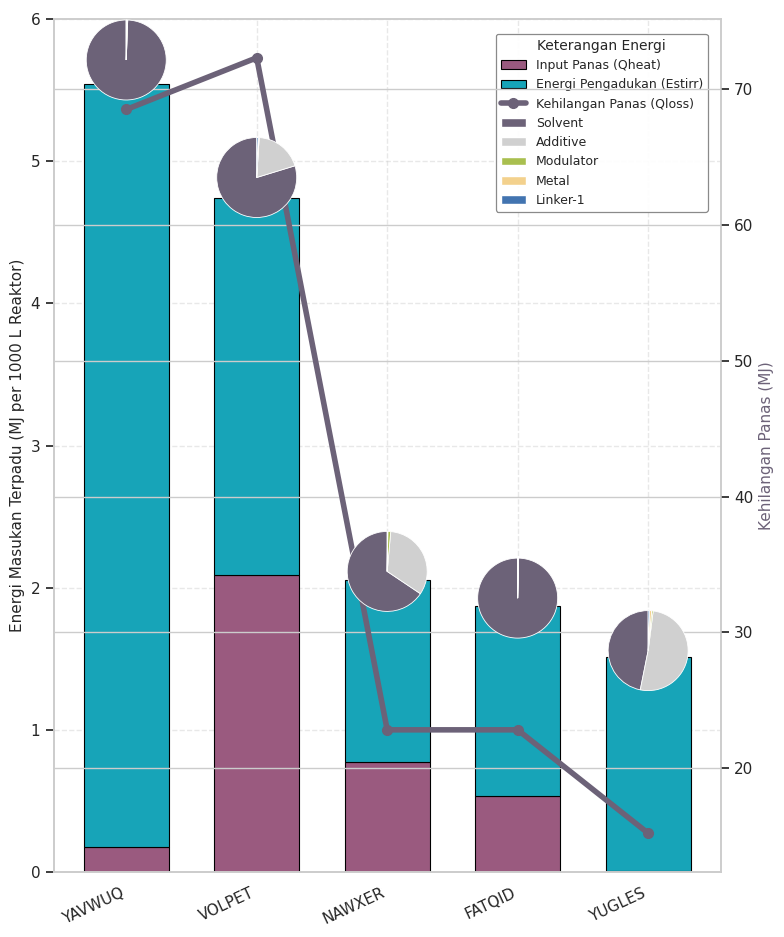

In [ ]:
# INTEGRATED ENERGY FINGERPRINT
# HITUNG TOTAL ENERGI SENSIBEL (J)
energy_components_J = [
    'Solvent_Energy (J)',
    'Additive_Energy (J)',
    'Modulator_Energy (J)',
    'Metal_Energy (J)',
    'Linker1_Energy (J)',
    'Linker2_Energy (J)'
]

energy_table['Total_Sensible_Energy (J)'] = (
    energy_table[energy_components_J].sum(axis=1)
)

# KONVERSI ENERGI SENSIBEL → MJ
energy_table_MJ = energy_table.copy()
for col in energy_components_J:
    energy_table_MJ[col.replace('(J)', '(MJ)')] = energy_table_MJ[col] / 1e6
energy_table_MJ['Total_Sensible_Energy (MJ)'] = (
    energy_table_MJ['Total_Sensible_Energy (J)'] / 1e6
)

# HITUNG TOTAL INPUT ENERGY & SORT
comparison_table['Total_Input_Energy'] = (
    comparison_table['Qheat_MJ_1000L'] +
    comparison_table['Estirr_MJ']
)
comparison_table = (
    comparison_table
    .sort_values('Total_Input_Energy', ascending=False)
    .reset_index(drop=True)
)

# sinkronisasi urutan MOF
energy_table_MJ = (
    energy_table_MJ
    .set_index('MOF_Name')
    .loc[comparison_table['MOF_Name']]
    .reset_index()
)

# PARAMETER PLOT
x = np.arange(len(comparison_table))
width = 0.65
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 9.5))

# WARNA
color_qheat  = FILL_COLORS[3]
color_estirr = FILL_COLORS[0]
color_qloss  = FILL_COLORS[5]

# pie sensible energy
palette_sensible = [
    FILL_COLORS[5],  # Solvent
    "#D0D0D0",       # Additive
    FILL_COLORS[1],  # Modulator
    FILL_COLORS[2],  # Metal
    FILL_COLORS[4]   # Linker-1
]
sensible_cols_MJ = [
    'Solvent_Energy (MJ)',
    'Additive_Energy (MJ)',
    'Modulator_Energy (MJ)',
    'Metal_Energy (MJ)',
    'Linker1_Energy (MJ)'
]
sensible_labels = [
    'Solvent', 'Additive', 'Modulator',
    'Metal', 'Linker-1'
]

# STACKED BAR — INPUT ENERGY
bars_qheat = ax.bar(
    x,
    comparison_table['Qheat_MJ_1000L'],
    width,
    color=color_qheat,
    label='Input Panas (Qheat)',
    edgecolor='black',
    linewidth=0.8
)
bars_estirr = ax.bar(
    x,
    comparison_table['Estirr_MJ'],
    width,
    bottom=comparison_table['Qheat_MJ_1000L'],
    color=color_estirr,
    label='Energi Pengadukan (Estirr)',
    edgecolor='black',
    linewidth=0.8
)
bar_tops = (
    comparison_table['Qheat_MJ_1000L'] +
    comparison_table['Estirr_MJ']
)
ax.set_ylim(top=6)

# GARIS QLOSS (SECONDARY AXIS)
ax2 = ax.twinx()
ax2.plot(
    x,
    comparison_table['Qloss_MJ'],
    color=color_qloss,
    marker='o',
    linewidth=4,
    markersize=7,
    label='Kehilangan Panas (Qloss)'
)

# PIE CHART ENERGI SENSIBEL
for i, xpos in enumerate(x):
    sensible_values = energy_table_MJ.loc[i, sensible_cols_MJ].values
    pie_ax = inset_axes(
        ax,
        width=1,
        height=1,
        bbox_to_anchor=(xpos, bar_tops.iloc[i] * 1.03),
        bbox_transform=ax.transData,
        loc='center',
        borderpad=0
    )
    pie_ax.pie(
        sensible_values,
        colors=palette_sensible,
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=0.6)
    )
    pie_ax.set_aspect('equal')
    pie_ax.axis('off')


# LABEL & TITLE
ax.set_xticks(x)
ax.set_xticklabels(
    comparison_table['MOF_Name'],
    rotation=25,
    ha='right'
)
ax.set_ylabel(
    "Energi Masukan Terpadu (MJ per 1000 L Reaktor)",
    fontsize=11
)
ax2.set_ylabel(
    "Kehilangan Panas (MJ)",
    fontsize=11,
    color=color_qloss
)

# GRID & SPINES
ax.grid(True, linestyle='--', alpha=0.45)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_linewidth(1.1)
ax2.spines['right'].set_linewidth(1.1)
ax2.spines['top'].set_linewidth(1.1)


# SINGLE COMBINED LEGEND (ALL IN ONE)
from matplotlib.patches import Patch

# legend dari bar & line
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# legend manual untuk pie chart (energi sensibel)
sensible_handles = [
    Patch(facecolor=palette_sensible[0], edgecolor='white', label='Solvent'),
    Patch(facecolor=palette_sensible[1], edgecolor='white', label='Additive'),
    Patch(facecolor=palette_sensible[2], edgecolor='white', label='Modulator'),
    Patch(facecolor=palette_sensible[3], edgecolor='white', label='Metal'),
    Patch(facecolor=palette_sensible[4], edgecolor='white', label='Linker-1')
]

# gabungkan semua
all_handles = lines1 + lines2 + sensible_handles
all_labels = labels1 + labels2 + [h.get_label() for h in sensible_handles]

legend = ax.legend(
    all_handles,
    all_labels,
    loc='upper right',
    bbox_to_anchor=(0.99, 0.99),
    frameon=True,
    fancybox=True,
    framealpha=0.92,
    fontsize=9,
    title='Keterangan Energi',
    title_fontsize=10
)
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(0.9)
plt.tight_layout()
plt.show()

# PLOTLY PIE CHART — SENSIBLE ENERGY DISTRIBUTION (5 MOF)
palette_sensible = [
    FILL_COLORS[5],   # Solvent
    "#D0D0D0",        # Additive
    FILL_COLORS[1],  # Modulator
    FILL_COLORS[2],  # Metal
    FILL_COLORS[4],  # Linker-1
    FILL_COLORS[3],  # Linker-2
]

# KOMPONEN ENERGI SENSIBEL
sensible_cols_MJ = [
    'Solvent_Energy (MJ)',
    'Additive_Energy (MJ)',
    'Modulator_Energy (MJ)',
    'Metal_Energy (MJ)',
    'Linker1_Energy (MJ)',
    'Linker2_Energy (MJ)'
]
sensible_labels = [
    'Solvent',
    'Additive',
    'Modulator',
    'Metal',
    'Linker-1',
    'Linker-2'
]

# SUBPLOT PIE
n_mof = len(energy_table_MJ)
fig = make_subplots(
    rows=1,
    cols=n_mof,
    specs=[[{"type": "domain"}] * n_mof],
    subplot_titles=energy_table_MJ["MOF_Name"]
)

# TAMBAHKAN PIE CHART
for i in range(n_mof):
    sensible_values = energy_table_MJ.loc[i, sensible_cols_MJ].values
    fig.add_trace(
        go.Pie(
            labels=sensible_labels,
            values=sensible_values,
            hole=0,
            sort=False,
            direction="clockwise",
            marker=dict(
                colors=palette_sensible,
                line=dict(color="white", width=1)
            ),
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Energi: %{value:.6f} MJ<br>"
                "Fraksi: %{percent}<extra></extra>"
            ),
            textinfo="none",
            showlegend=(i == 0)
        ),
        row=1,
        col=i + 1
    )

# LAYOUT GLOBAL
fig.update_layout(
    title=dict(
        text="Distribusi Energi Sensibel pada Setiap MOF",
        x=0.5,
        xanchor="center",
        font=dict(size=18)
    ),
    font=dict(
        family="Arial",
        size=13
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1400,
    height=420,
    legend=dict(
        orientation="v",
        x=1.02,
        y=0.95,
        bordercolor="black",
        borderwidth=1,
        title=dict(text="Komponen Energi Sensibel")
    ),
    margin=dict(t=80, l=40, r=180, b=40)
)
fig.show()

# PLOTLY PIE CHART — ZOOM SENSIBLE ENERGY (MINOR COMPONENTS)
# KOMPONEN ENERGI MINOR (TANPA SOLVENT & ADDITIVE)
zoom_cols_MJ = [
    'Modulator_Energy (MJ)',
    'Metal_Energy (MJ)',
    'Linker1_Energy (MJ)'
]
zoom_labels = [
    'Modulator',
    'Metal',
    'Linker-1',
    'Linker-2'
]
zoom_colors = [
    palette_sensible[2], # Modulator
    palette_sensible[3], # Metal
    palette_sensible[4]  # Linker-1
]

# SUBPLOT PIE — 1 ZOOM PIE PER MOF
n_mof = len(energy_table_MJ)
fig_zoom = make_subplots(
    rows=1,
    cols=n_mof,
    specs=[[{"type": "domain"}] * n_mof],
    subplot_titles=energy_table_MJ["MOF_Name"]
)

# TAMBAHKAN ZOOM PIE
for i in range(n_mof):
    zoom_values = energy_table_MJ.loc[i, zoom_cols_MJ].values
    fig_zoom.add_trace(
        go.Pie(
            labels=zoom_labels,
            values=zoom_values,
            hole=0,
            sort=False,
            direction="clockwise",
            marker=dict(
                colors=zoom_colors,
                line=dict(color="white", width=1)
            ),
            hovertemplate=(
                "<b>%{label}</b><br>"
                "Energi: %{value:.2f} MJ<br>"
                "Fraksi (zoom): %{percent}<extra></extra>"
            ),
            textinfo="none",
            showlegend=(i == 0)
        ),
        row=1,
        col=i + 1
    )

# LAYOUT GLOBAL
fig_zoom.update_layout(
    title=dict(
        text="Zoom Distribusi Energi Sensibel (Komponen Minor)",
        x=0.5,
        xanchor="center",
        font=dict(size=18)
    ),
    font=dict(
        family="Arial",
        size=13
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=1400,
    height=420,
    legend=dict(
        orientation="v",
        x=1.02,
        y=0.95,
        bordercolor="black",
        borderwidth=1,
        title=dict(text="Komponen Energi Sensibel (Zoom)")
    ),
    margin=dict(t=80, l=40, r=180, b=40)
)
fig_zoom.show()

12. Visualisasi Energi Sintesis PCA Biplot

In [ ]:
# penyusunan tabel diagnostik kontribusi energi
cp_table = cp_table.drop_duplicates(subset='MOF_Name')

merged = merged.drop(columns=[
    'Solvent_Cp', 'Additive_Cp', 'Modulator_Cp', 'Metal_Cp',
    'Linker1_Cp_J_per_molK', 'Linker2_Cp_J_per_molK',
    'Linker1_Cp', 'Linker2_Cp'
], errors='ignore')

merged = merged.merge(cp_table, on='MOF_Name', how='left')

merged = merged.rename(columns={
    'Linker1_Cp_J_per_molK': 'Linker1_Cp',
    'Linker2_Cp_J_per_molK': 'Linker2_Cp'
})

merged = merged.loc[:, ~merged.columns.duplicated()]

# perhitungan parameter densitas
merged['Density_Liquid (g/L)'] = (
    merged['m_Liquid'] / merged['V_Liquid (L)']
).replace([float('inf'), 0], np.nan).fillna(1000)

merged['Density_Solid (g/L)'] = 2500
merged['Density_Total (g/L)'] = (
    merged['Density_Tot'] if 'Density_Tot' in merged.columns else np.nan
)

# pembentukan tabel diagnostik energi
diagnostic_table = merged[[
    'MOF_Name',
    'Temperature (oC)',
    'Delta_T (K)',
    'Time (h)',
    'Density_Liquid (g/L)',
    'Density_Solid (g/L)',
    'Density_Total (g/L)',
    'Solvent_Cp', 'Additive_Cp', 'Modulator_Cp', 'Metal_Cp',
    'Linker1_Cp', 'Linker2_Cp',
    'Solvent_Mol (mol)', 'Additive_Mol (mol)', 'Modulator_Mol (mol)',
    'Metal_Mol (mol)', 'Linker1_Mol (mol)', 'Linker2_Mol (mol)',
    'Qheat_MJ_1000L',
    'Qloss_MJ',
    'Estirr_MJ'
]].copy()

diagnostic_table = diagnostic_table.rename(columns={
    'Temperature (oC)': 'Temperature (°C)',
    'Delta_T (K)': 'ΔT (K)',
    'Qheat_MJ_1000L': 'Qheat (MJ/1000L)',
    'Qloss_MJ': 'Qloss (MJ)',
    'Estirr_MJ': 'Stirring Energy (MJ)'
})

diagnostic_table = diagnostic_table.loc[:, ~diagnostic_table.columns.duplicated()]
diagnostic_table = diagnostic_table.reset_index(drop=True)

# PCA BIPLOT
sns.set_theme(style="whitegrid", font_scale=1.1)

X = diagnostic_table[
    [
        'Density_Liquid (g/L)',
        'Temperature (°C)', 'Time (h)',
        'Additive_Cp', 'Modulator_Cp', 'Metal_Cp',
        'Linker1_Cp', 'Linker2_Cp',
        'Qheat (MJ/1000L)', 'Qloss (MJ)', 'Stirring Energy (MJ)'
    ]
].copy()
X = X.apply(pd.to_numeric, errors='coerce').dropna()

# STANDARDIZATION & PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# PCA RESULT TABLE
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['MOF_Name'] = diagnostic_table.loc[X.index, 'MOF_Name']
if 'Total_Energy (MJ)' not in diagnostic_table.columns:
    diagnostic_table['Total_Energy (MJ)'] = diagnostic_table[
        ['Qheat (MJ/1000L)', 'Qloss (MJ)', 'Stirring Energy (MJ)']
    ].sum(axis=1)
pca_df['Total_Energy (MJ)'] = diagnostic_table.loc[X.index, 'Total_Energy (MJ)']

# PCA LOADINGS
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

# PCA BIPLOT (PLOTLY)
fig = go.Figure()

# scatter MOF points
fig.add_trace(
    go.Scatter(
        x=pca_df['PC1'],
        y=pca_df['PC2'],
        mode="markers",
        showlegend=False,
        text=pca_df['MOF_Name'],
        hovertemplate=(
            "<b>%{text}</b><br>"
            "PC1 = %{x:.2f}<br>"
            "PC2 = %{y:.2f}<br>"
            "Energi = %{marker.color:.2f} MJ"
            "<extra></extra>"
        ),
          marker=dict(
            size=26,
            color=pca_df['Total_Energy (MJ)'],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Energi Total (MJ)",
                titleside="right",
                tickangle=0,
                ticks="outside",
                ticklen=8,
                tickwidth=2,
                outlinewidth=1,
                outlinecolor="black"
            ),
            line=dict(color="black", width=1),
            opacity=0.9
        )

    )
)
arrow_scale = 2.5
for i, var in enumerate(loadings.index):
    code = f"C{i+1}"
    fig.add_trace(
        go.Scatter(
            x=[0, loadings.iloc[i, 0] * arrow_scale],
            y=[0, loadings.iloc[i, 1] * arrow_scale],
            mode="lines",
            line=dict(color="gray", width=2),
            hovertemplate=(
                f"<b>{code}</b><br>"
                f"{var}<br>"
                "PC1 loading = %{x:.2f}<br>"
                "PC2 loading = %{y:.2f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# reference lines
fig.add_hline(y=0, line=dict(color="gray", width=1, dash="dash"))
fig.add_vline(x=0, line=dict(color="gray", width=1, dash="dash"))

fig.update_layout(
    **base_layout(
        title="Lanskap Energi (PCA Biplot)",
        x_title=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)",
        y_title=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)",
    )
)
fig.update_xaxes(
    range=[-3, 4],
    dtick=1,
    tick0=-3
)
fig.update_yaxes(
    range=[-3, 4],
    dtick=1,
    tick0=-3
)

# tick keluar
fig.update_xaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    ticks="outside",
    ticklen=8,
    tickwidth=1.5
)
fig.update_yaxes(
    showline=True,
    linewidth=1,
    linecolor="black",
    mirror=True,
    ticks="outside",
    ticklen=8,
    tickwidth=1.5
)
fig.update_layout(
    width=600,
    height=600
)
fig.show()

# PCA LOADING SUMMARY TABLE
loading_summary = loadings.copy()
loading_summary['Magnitude'] = np.sqrt(
    loading_summary['PC1']**2 + loading_summary['PC2']**2
)
loading_summary = loading_summary.sort_values('Magnitude', ascending=False)
display(
    loading_summary
    .round(6)
    .style
    .background_gradient(cmap='viridis')
    .set_caption("Kontribusi Variabel terhadap PCA (Variable Loadings)")
)

# TABEL KOORDINAT 5 MOF (ENERGI TERTINGGI)
# pilih 5 MOF dengan energi total tertinggi
top5_mof = (
    pca_df
    .sort_values('Total_Energy (MJ)', ascending=False)
    .head(5)
    .copy()
)

# normalisasi energi untuk warna
norm = plt.Normalize(
    pca_df['Total_Energy (MJ)'].min(),
    pca_df['Total_Energy (MJ)'].max()
)

# ambil warna aktual dari colormap
top5_mof['Color (viridis)'] = top5_mof['Total_Energy (MJ)'].apply(
    lambda x: plt.cm.viridis(norm(x))
)

# tabel ringkas
top5_mof_table = top5_mof[[
    'MOF_Name', 'PC1', 'PC2', 'Total_Energy (MJ)', 'Color (viridis)'
]].round(3)

print("\n=== KOORDINAT PCA & ENERGI — 5 MOF DOMINAN ===\n")
display(top5_mof_table)

# TABEL KOORDINAT PANAH PARAMETER (LOADINGS)
arrow_scale = 2.5
arrow_table = loadings.copy()
arrow_table['Arrow_X'] = arrow_table['PC1'] * arrow_scale
arrow_table['Arrow_Y'] = arrow_table['PC2'] * arrow_scale
arrow_table['Magnitude'] = np.sqrt(
    arrow_table['Arrow_X']**2 + arrow_table['Arrow_Y']**2
)
arrow_table = arrow_table.reset_index().rename(columns={'index': 'Parameter'})
arrow_table = arrow_table.sort_values('Magnitude', ascending=False)
arrow_table = arrow_table.round(3)
print("\n=== KOORDINAT PANAH PARAMETER (PCA LOADINGS) ===\n")
display(arrow_table)

,PC1,PC2,Magnitude
Qheat (MJ/1000L),0.142348,0.455844,0.477553
Temperature (°C),0.134893,0.457724,0.477187
Metal_Cp,-0.053755,-0.445680,0.448911
Stirring Energy (MJ),0.398539,-0.196002,0.444129
Linker2_Cp,0.328462,-0.295712,0.441965
Time (h),0.403936,-0.178696,0.441698
Qloss (MJ),0.425255,0.103856,0.437754
Modulator_Cp,-0.344811,-0.234645,0.417076
Linker1_Cp,-0.382428,0.150269,0.410892
Density_Liquid (g/L),-0.164184,-0.351226,0.387706



=== KOORDINAT PCA & ENERGI — 5 MOF DOMINAN ===



,MOF_Name,PC1,PC2,Total_Energy (MJ),Color (viridis)
3,VOLPET,1.980,3.008,77.039,"(0.993248, 0.906157, 0.143936, 1.0)"
4,YAVWUQ,3.382,-2.430,74.036,"(0.876168, 0.891125, 0.09525, 1.0)"
0,NAWXER,-1.807,1.327,24.883,"(0.277134, 0.185228, 0.489898, 1.0)"
1,FATQID,-1.143,0.050,24.701,"(0.278012, 0.180367, 0.486697, 1.0)"
2,YUGLES,-2.411,-1.956,16.732,"(0.267004, 0.004874, 0.329415, 1.0)"



=== KOORDINAT PANAH PARAMETER (PCA LOADINGS) ===



,Parameter,PC1,PC2,Arrow_X,Arrow_Y,Magnitude
8,Qheat (MJ/1000L),0.142,0.456,0.356,1.140,1.194
1,Temperature (°C),0.135,0.458,0.337,1.144,1.193
5,Metal_Cp,-0.054,-0.446,-0.134,-1.114,1.122
10,Stirring Energy (MJ),0.399,-0.196,0.996,-0.490,1.110
7,Linker2_Cp,0.328,-0.296,0.821,-0.739,1.105
2,Time (h),0.404,-0.179,1.010,-0.447,1.104
9,Qloss (MJ),0.425,0.104,1.063,0.260,1.094
4,Modulator_Cp,-0.345,-0.235,-0.862,-0.587,1.043
6,Linker1_Cp,-0.382,0.150,-0.956,0.376,1.027
0,Density_Liquid (g/L),-0.164,-0.351,-0.410,-0.878,0.969


13. Visualisasi Energi Sintesis - Peta Sensitivitas Energi

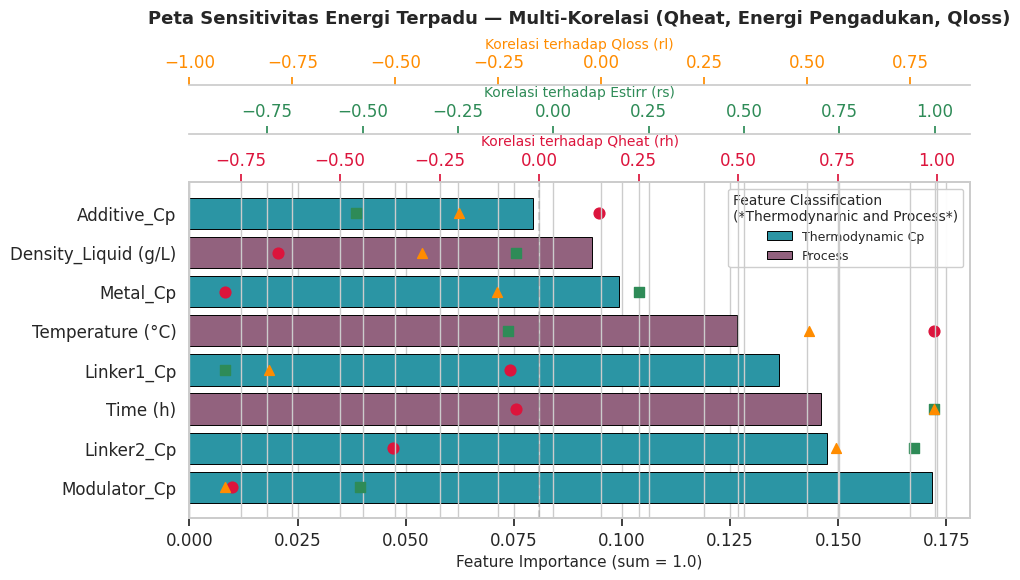


=== TABEL KORELASI LENGKAP FEATURE vs ENERGI ===



,Feature,Type,r_Qheat,r_Stirring,r_Qloss,Mean |r|
4,Modulator_Cp,Thermodynamic Cp,-0.773,-0.506,-0.914,0.731
7,Linker2_Cp,Thermodynamic Cp,-0.367,0.947,0.569,0.628
1,Time (h),Process,-0.058,0.999,0.807,0.621
6,Linker1_Cp,Thermodynamic Cp,-0.073,-0.861,-0.807,0.580
0,Temperature (°C),Process,0.993,-0.120,0.504,0.539
5,Metal_Cp,Thermodynamic Cp,-0.790,0.224,-0.253,0.422
2,Density_Liquid (g/L),Process,-0.656,-0.097,-0.435,0.396
3,Additive_Cp,Thermodynamic Cp,0.151,-0.517,-0.346,0.338


In [ ]:
# pemetaan sensitivitas energi berbasis multi-korelasi
df_obj = diagnostic_table.copy()

mapping_targets = {
    'Qheat (MJ/1000L)': 'Qheat (MJ/1000L)',
    'Stirring Energy (MJ)': 'Stirring Energy (MJ)',
    'Qloss (MJ)': 'Qloss (MJ)'
}
default_features = [
    'Temperature (°C)', 'Time (h)',
    'Density_Liquid (g/L)', 'Additive_Cp', 'Modulator_Cp', 'Metal_Cp',
    'Linker1_Cp', 'Linker2_Cp'
]

# perhitungan tingkat kepentingan fitur berdasarkan korelasi
features = [f for f in default_features if f in df_obj.columns]
available_targets = [t for t in mapping_targets.values() if t in df_obj.columns]

corrs = []
for f in features:
    vals = []
    for t in available_targets:
        try:
            r = df_obj[[f, t]].corr().iloc[0, 1]
        except Exception:
            r = 0
        vals.append(0 if pd.isna(r) else abs(r))
    corrs.append(np.nanmean(vals))

importance = np.array(corrs)
if importance.sum() > 0:
    importance = importance / importance.sum()

# evaluasi korelasi individual antara fitur dan energi
corr_data = {}
for label, colname in mapping_targets.items():
    if colname in df_obj.columns:
        corr_series = []
        for f in features:
            if f in df_obj.columns:
                r = df_obj[[f, colname]].corr().iloc[0, 1]
                corr_series.append(0 if pd.isna(r) else r)
            else:
                corr_series.append(0)
        corr_data[label] = np.array(corr_series)
    else:
        corr_data[label] = np.zeros(len(features))

# klasifikasi fitur menjadi kelompok proses dan termodinamika
types = [
    'Process' if any(k.lower() in f.lower() for k in ['temp', 'time', 'density'])
    else 'Thermodynamic Cp'
    for f in features
]

# penggabungan data korelasi dan kepentingan fitur
combo = pd.DataFrame({
    'Feature': features,
    'Importance': importance[:len(features)],
    'Qheat': corr_data['Qheat (MJ/1000L)'],
    'Stirring': corr_data['Stirring Energy (MJ)'],
    'Qloss': corr_data['Qloss (MJ)'],
    'Type': types
}).fillna(0)
combo = combo.sort_values('Importance', ascending=True).reset_index(drop=True)

# visualisasi peta korelasi multi-energi
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax1 = plt.subplots(figsize=(10, 6))

# visualisasi utama untuk kepentingan fitur
bar = sns.barplot(
    data=combo, y='Feature', x='Importance', hue='Type',
    palette=[FILL_COLORS[0], FILL_COLORS[3]],  # biru → 4, orange → 3
    dodge=False,
    ax=ax1, edgecolor='black', linewidth=0.7
)
ax1.set_xlabel('Feature Importance (sum = 1.0)', fontsize=11)
ax1.set_ylabel('')
feature_legend = ax1.legend(
    title='Feature Classification',
    loc='upper right', frameon=True, fancybox=True, framealpha=0.95,
    title_fontsize=10, fontsize=9
)
feature_legend.set_title('Feature Classification\n(*Thermodynamic and Process*)')

colors = {
    'Qheat (MJ/1000L)': 'crimson',
    'Stirring Energy (MJ)': 'seagreen',
    'Qloss (MJ)': 'darkorange'
}

# integrasi tiga sumbu korelasi energi pada satu plot
ax2 = ax1.twiny()
ax2.scatter(combo['Qheat'], combo['Feature'],
            color=colors['Qheat (MJ/1000L)'], s=60,
            label='Qheat (r)', zorder=5)
ax2.set_xlabel('Korelasi terhadap Qheat (rh)', color=colors['Qheat (MJ/1000L)'], fontsize=10)
ax2.tick_params(axis='x', colors=colors['Qheat (MJ/1000L)'])
ax2.axvline(0, color='gray', linestyle='--', alpha=0.3)

ax3 = ax1.twiny()
ax3.spines['top'].set_position(('outward', 35))
ax3.scatter(combo['Stirring'], combo['Feature'],
            color=colors['Stirring Energy (MJ)'], s=50, marker='s',
            label='Stirring Energy (r)', zorder=4)
ax3.set_xlabel('Korelasi terhadap Estirr (rs)', color=colors['Stirring Energy (MJ)'], fontsize=10)
ax3.tick_params(axis='x', colors=colors['Stirring Energy (MJ)'])

ax4 = ax1.twiny()
ax4.spines['top'].set_position(('outward', 70))
ax4.scatter(combo['Qloss'], combo['Feature'],
            color=colors['Qloss (MJ)'], s=50, marker='^',
            label='Qloss (r)', zorder=3)
ax4.set_xlabel('Korelasi terhadap Qloss (rl)', color=colors['Qloss (MJ)'], fontsize=10)
ax4.tick_params(axis='x', colors=colors['Qloss (MJ)'])

plt.title(
    'Peta Sensitivitas Energi Terpadu — Multi-Korelasi (Qheat, Energi Pengadukan, Qloss)',
    fontsize=13, weight='bold', pad=10
)
plt.tight_layout()
plt.show()

# TABEL KORELASI LENGKAP FEATURE vs ENERGI
corr_table = pd.DataFrame({
    'Feature': features,
    'Type': types,
    'r_Qheat': corr_data['Qheat (MJ/1000L)'],
    'r_Stirring': corr_data['Stirring Energy (MJ)'],
    'r_Qloss': corr_data['Qloss (MJ)']
})

# pembulatan agar rapi di laporan
corr_table[['r_Qheat', 'r_Stirring', 'r_Qloss']] = (
    corr_table[['r_Qheat', 'r_Stirring', 'r_Qloss']].round(3)
)

# urutkan berdasarkan |r| rata-rata
corr_table['Mean |r|'] = (
    corr_table[['r_Qheat', 'r_Stirring', 'r_Qloss']]
    .abs()
    .mean(axis=1)
    .round(3)
)
corr_table = corr_table.sort_values('Mean |r|', ascending=False)
print("\n=== TABEL KORELASI LENGKAP FEATURE vs ENERGI ===\n")
display(corr_table)